# Summary: Training Products of Experts by Minimizing Contrastive Divergence

# https://www.cs.toronto.edu/~fritz/absps/tr00-004.pdf

## Abstract
This paper (Hinton, 2000, Gatsby TR 2000-004) introduces a training method for Products of Experts (PoE) models, in which several probabilistic models are combined by multiplying their distributions and renormalizing. While PoEs can represent sharp, high-dimensional distributions efficiently, they are difficult to train with maximum likelihood because it requires sampling from the model's equilibrium distribution. The paper proposes minimizing "contrastive divergence" (CD), an alternative objective that requires only brief Gibbs sampling, making PoE training tractable and efficient. The method is validated on synthetic data, handwritten digit modeling, and discriminative digit classification.

## Problems
- **Mixture models are inefficient in high dimensions**: mixtures of simple models cannot produce distributions sharper than their individual components, requiring exponentially many components to model high-dimensional structured data (e.g., a 35-dimensional face manifold).
- **Maximum likelihood training of PoEs is intractable**: computing the gradient of the log-likelihood requires the derivative of the partition function, which involves an expectation over the model's equilibrium distribution $Q^\infty$, obtained only via prolonged Gibbs sampling or rejection sampling.
- **High variance in gradient estimates**: even when equilibrium sampling is feasible, the resulting samples have high variance that swamps the true gradient signal, and this variance itself depends on the parameters, causing spurious parameter drift even when the true gradient is zero.

## Proposed Solutions
- **Products of Experts (PoE) formulation**: combine $n$ individual expert distributions $p_m(\mathbf{d}|\theta_m)$ via
$$
p(\mathbf{d}|\theta_1 \dots \theta_n) = \frac{\prod_m p_m(\mathbf{d}|\theta_m)}{\sum_{\mathbf{c}} \prod_m p_m(\mathbf{c}|\theta_m)}
$$
so each expert constrains a different subset of dimensions, letting the product yield sharp, high-dimensional posteriors.
- **Contrastive Divergence (CD) learning**: instead of minimizing the KL divergence $Q^0\|Q^\infty$ between the data distribution and the model's equilibrium distribution, minimize the difference
$$
CD = Q^0\|Q^\infty - Q^1\|Q^\infty
$$
where $Q^1$ is the distribution after one full step of Gibbs sampling starting from the data. This avoids running the Markov chain to convergence.
- **Approximate gradient rule**: the parameter update ignores the (empirically small) third term arising from the dependence of $Q^1$ on the parameters, yielding the simple, tractable rule
$$
\Delta\theta_m \propto \left\langle \frac{\partial \log p_m(\mathbf{d}|\theta_m)}{\partial \theta_m}\right\rangle_{Q^0} - \left\langle \frac{\partial \log p_m(\hat{\mathbf{d}}|\theta_m)}{\partial \theta_m}\right\rangle_{Q^1}
$$
where $\hat{\mathbf{d}}$ is a one-step reconstruction of the data.

## Purpose
The work aims to make PoE models practically trainable so that their representational advantages—efficient modeling of high-dimensional data satisfying multiple simultaneous constraints—can be exploited, and to connect this training procedure to existing models such as Restricted Boltzmann Machines (RBMs), showing CD as a generally applicable, low-variance, efficient learning principle.

## Methodology
- **General procedure**: (1) sample a data vector $\mathbf{d}$ from $Q^0$; (2) compute each expert's posterior over its latent variables given $\mathbf{d}$; (3) sample latent states; (4) compute the conditional distribution over visible variables by multiplying the experts' conditional distributions; (5) sample a reconstruction $\hat{\mathbf{d}}$; then apply the CD-based weight update.
- **RBM instantiation**: an RBM is treated as a PoE with one expert per hidden unit. The CD rule reduces to the classic contrastive Hebbian update:
$$
\Delta w_{ij} \propto \langle s_i s_j \rangle_{Q^0} - \langle s_i s_j \rangle_{Q^1}
$$
- **Experimental setups**:
  - A toy 2D example with 15 "unigauss" experts (mixture of uniform and axis-aligned Gaussian) fit to clustered data via 2,000 parameter updates.
  - A population-coding experiment with experts fit to 100-dimensional synthetic edge images.
  - An RBM with 500 hidden units and 256 visible units trained on 8,000 16×16 USPS handwritten digit images (all 10 classes) using probability-valued reconstructions (Eq. 11), mini-batches of 100, momentum, 658 epochs.
  - Discriminative models: separate class-specific PoEs (including two-hidden-layer variants) trained on individual digit classes (e.g., 2 vs. 3, 4 vs. 6, 7 vs. 9), with unnormalized log-probability scores combined via logistic regression across 10 classes.
  - Quantitative validation of the CD approximation via small RBMs (8 visible/4 hidden and 10/10 units) where exact expectations under $Q^\infty$ and $Q^1$ could be computed, comparing modeled vs. unmodeled gradient terms.

## Results
- The 15-expert toy model successfully captured clustered 2D data structure via intersecting Gaussians, with Gibbs-sampled fantasy data closely matching the true distribution, including correctly reproducing missing grid points.
- Experts trained on synthetic edge images learned edge-detector-like receptive fields analogous to biological feature detectors.
- The RBM trained on USPS digits learned localized features (stroke fragments, Gabor-like filters, center-surround fields) yielding near-perfect reconstructions using roughly one-third active features per image.
- Class-specific PoE models achieved strong discrimination: near-perfect separation for easier digit pairs (e.g., 4 vs. 6) and good but imperfect separation for harder pairs (e.g., 7 vs. 9), with errors occurring only near decision boundaries.
- The full 10-class system (using two-hidden-layer PoEs and logistic regression on unnormalized scores) achieved a **1.1% error rate**, substantially better than a nearest-neighbor baseline (5.1%) and comparable to the best elastic-model-based classifiers; with 7% rejection, zero errors were observed on 2,750 test images.
- Empirical validation on small RBMs showed that the ignored gradient term is small and its sign almost never opposes the true gradient direction, confirming the approximation's validity; the CD update reliably improved contrastive divergence and, less consistently but still favorably, log-likelihood.

## Conclusions
- Contrastive divergence provides an efficient, low-variance, and empirically reliable approximation to maximum likelihood learning for Products of Experts, circumventing the need for equilibrium sampling.
- The method exactly recovers standard RBM learning as a special case, unifying Boltzmann machine-style learning with the broader PoE framework.
- PoEs trained via CD combine tractable, rapid inference (due to conditional independence of experts' latent variables given data) with strong generative and discriminative performance, though generating fantasy data remains comparatively harder than in directed generative models.
- The approach generalizes beyond binary RBMs to other expert types (e.g., "unigauss" mixtures, replicated units for real-valued approximation, products of Hidden Markov Models), suggesting broad applicability of contrastive divergence as a general training principle for products of tractable experts.

# Mathematical and Statistical Content Summary

## 1. Product of Experts Formula (Eq. 1)
$$
p(\mathbf{d}|\theta_1 \dots \theta_n) = \frac{\prod_m p_m(\mathbf{d}|\theta_m)}{\sum_{\mathbf{c}} \prod_m p_m(\mathbf{c}|\theta_m)}
$$
**Role**: Defines how individual "expert" probability distributions $p_m$ are combined by multiplying them together and renormalizing (dividing by the sum over all possible data vectors $\mathbf{c}$). This is the core generative model of the paper — each expert constrains part of the data space, and multiplication sharpens the joint distribution.

## 2. Maximum Likelihood Gradient (Eq. 2)
$$
\frac{\partial \log p(\mathbf{d}|\theta_1\dots\theta_n)}{\partial \theta_m} = \frac{\partial \log p_m(\mathbf{d}|\theta_m)}{\partial \theta_m} - \sum_{\mathbf{c}} p(\mathbf{c}|\theta_1\dots\theta_n) \frac{\partial \log p_m(\mathbf{c}|\theta_m)}{\partial \theta_m}
$$
**Role**: Standard gradient-ascent rule for fitting the model to data. The first term increases the probability the expert gives to real data; the second term (an expectation over "fantasy" data generated by the model) decreases the expert's probability everywhere else. The second term is the source of the intractability the paper addresses.

## 3. Kullback-Leibler (KL) Divergence and its Decomposition (Eq. 3)
$$
Q^0\|Q^\infty = \sum_{\mathbf{d}} Q^0_{\mathbf{d}} \log Q^0_{\mathbf{d}} - \sum_{\mathbf{d}} Q^0_{\mathbf{d}} \log Q^\infty_{\mathbf{d}} = -H(Q^0) - \langle \log Q^\infty_{\mathbf{d}} \rangle_{Q^0}
$$
**Role**: KL divergence measures how different two probability distributions are. Here $Q^0$ is the real data distribution and $Q^\infty$ is the model's equilibrium distribution (reached after infinitely long Gibbs sampling). Maximizing likelihood is mathematically equivalent to minimizing this divergence. $H(Q^0)$ is the entropy of the data distribution, which is constant and irrelevant to optimization.

## 4. Gradient Rewritten via Expectations (Eq. 4)
$$
\left\langle \frac{\partial \log Q^\infty_{\mathbf{d}}}{\partial \theta_m} \right\rangle_{Q^0} = \left\langle \frac{\partial \log p_m(\mathbf{d}|\theta_m)}{\partial \theta_m} \right\rangle_{Q^0} - \left\langle \frac{\partial \log p_m(\mathbf{c}|\theta_m)}{\partial \theta_m} \right\rangle_{Q^\infty}
$$
**Role**: Restates Eq. 2 averaged over the data distribution, explicitly showing the gradient as a difference of two expectations — one under the data distribution, one under the model's own equilibrium distribution. This form motivates the contrastive divergence trick below.

## 5. Contrastive Divergence Objective
$$
CD = Q^0\|Q^\infty - Q^1\|Q^\infty
$$
**Role**: The paper's central innovation. Rather than driving $Q^0$ all the way to match $Q^\infty$ (requiring full equilibrium sampling), it only requires that one step of Gibbs sampling ($Q^1$) not move further away from the data than $Q^0$ already is. Since $Q^1$ is provably closer to $Q^\infty$ than $Q^0$ is, $CD \geq 0$, and $CD = 0$ only when the model is perfect.

## 6. Gradient of Contrastive Divergence (Eq. 5)
$$
-\frac{\partial}{\partial \theta_m}\left(Q^0\|Q^\infty - Q^1\|Q^\infty\right) = \left\langle \frac{\partial \log p_m(\mathbf{d}|\theta_m)}{\partial \theta_m}\right\rangle_{Q^0} - \left\langle \frac{\partial \log p_m(\hat{\mathbf{d}}|\theta_m)}{\partial \theta_m}\right\rangle_{Q^1} + \frac{\partial Q^1}{\partial \theta_m}\frac{\partial Q^1\|Q^\infty}{\partial Q^1}
$$
**Role**: Shows that differentiating the contrastive divergence causes the intractable equilibrium expectation over $Q^\infty$ to cancel out. What remains is (a) two tractable expectations — one over real data, one over one-step reconstructions $\hat{\mathbf{d}}$ — and (b) a third term that is difficult to compute but empirically small and safely ignorable.

## 7. Approximate Learning Rule (Eq. 6)
$$
\Delta\theta_m \propto \left\langle \frac{\partial \log p_m(\mathbf{d}|\theta_m)}{\partial \theta_m}\right\rangle_{Q^0} - \left\langle \frac{\partial \log p_m(\hat{\mathbf{d}}|\theta_m)}{\partial \theta_m}\right\rangle_{Q^1}
$$
**Role**: The practical training rule used throughout the paper — drop the problematic third term from Eq. 5. Parameters move to increase the log-probability of real data and decrease the log-probability of the model's own one-step reconstructions. This has low variance because reconstructions closely resemble the data (a "matched pairs" variance-reduction effect, analogous to paired experimental designs in statistics).

## 8. RBM-Specific Gradients (Eqs. 7–11)
$$
\frac{\partial \log p_j(\mathbf{d}|\mathbf{w}_j)}{\partial w_{ij}} = \langle s_i s_j \rangle_{\mathbf{d}} - \langle s_i s_j \rangle_{Q^\infty(j)} \quad (7)
$$
$$
\sum_{\mathbf{c}} p(\mathbf{c}|\mathbf{w}) \frac{\partial \log p_j(\mathbf{c}|\mathbf{w}_j)}{\partial w_{ij}} = \langle s_i s_j \rangle_{Q^\infty} - \langle s_i s_j \rangle_{Q^\infty(j)} \quad (8)
$$
$$
\left\langle \frac{\partial \log Q^\infty_{\mathbf{d}}}{\partial w_{ij}}\right\rangle_{Q^0} = \langle s_i s_j \rangle_{Q^0} - \langle s_i s_j \rangle_{Q^\infty} \quad (9)
$$
$$
-\frac{\partial}{\partial w_{ij}}\left(Q^0\|Q^\infty - Q^1\|Q^\infty\right) \approx \langle s_i s_j \rangle_{Q^0} - \langle s_i s_j \rangle_{Q^1} \quad (10)
$$
$$
-\frac{\partial}{\partial w_{ij}}\left(Q^0\|Q^\infty - Q^1\|Q^\infty\right) \approx \langle p_i p_j \rangle_{Q^0} - \langle p_i p_j \rangle_{Q^1} \quad (11)
$$
**Role**: Specializes the general PoE/CD framework to Restricted Boltzmann Machines, where each hidden unit is one "expert." $s_i, s_j$ are binary states of visible/hidden units; $\langle s_i s_j\rangle$ terms are correlations ("Hebbian" co-activation statistics). Eq. 10 is the classic RBM contrastive divergence rule (correlations from data minus correlations from one-step reconstructions). Eq. 11 is a real-valued (probability-based) variant used for the digit-image experiments, replacing stochastic binary states with their probabilities to reduce noise.

## 9. Logarithmic Opinion Pool Inequality (Eq. 12)
$$
P\left\|\frac{\prod_m Q_m^{w_m}}{Z}\right. \leq \sum_m w_m \, P\|Q_m
$$
where $Z = \sum_{\mathbf{c}} \prod_m Q_m^{w_m}(\mathbf{c})$.
**Role**: A theoretical justification for combining experts multiplicatively (a "log opinion pool"). It states that the KL divergence of the weighted geometric mean of expert distributions from the true distribution $P$ is never worse than the weighted average of the individual experts' divergences — i.e., combining experts this way is guaranteed to help, not hurt, on average. The gain comes from $-\log Z$, reflecting how much the experts "disagree" on unobserved data.

## 10. Statistical/Sampling Methods Used
- **Gibbs Sampling**: An iterative Markov Chain Monte Carlo (MCMC) method that alternately samples hidden variables given visible variables and vice versa, used to approximate $Q^1$ (one-step) and $Q^\infty$ (equilibrium) distributions. Its efficiency stems from the conditional independence of experts' hidden units given the visible data (a "bipartite graph" structure).
- **Rejection Sampling**: Mentioned as a conceptually simple but highly inefficient alternative for generating "fantasy" data from a PoE, where each expert proposes a sample independently until all agree.
- **Momentum in Optimization**: Parameter updates are supplemented by adding 0.9 times the previous update, a standard technique to accelerate gradient-based learning and dampen oscillation.
- **Logistic Regression**: Used as a discriminative classifier layer, converting unnormalized log-probability scores from 10 separate class-specific PoEs into a probability distribution over digit labels.
- **Empirical Validation via Small Exact Networks**: For small RBMs (8 visible/4 hidden; 10/10 units), exact expectations under $Q^\infty$ were computed by brute-force enumeration (exponential in unit count), enabling direct comparison of the true gradient against the CD approximation — used to statistically validate (via histograms and scatterplots) that the ignored term in Eq. 5 rarely opposes the true gradient direction.

## Summary of Purpose of the Math
The mathematical core of the paper solves a specific problem: computing the gradient needed to train a Product of Experts model requires an intractable expectation over the model's full equilibrium distribution. The key mathematical maneuver — replacing the KL divergence to equilibrium with the *difference* of two KL divergences (contrastive divergence) — causes the troublesome equilibrium term to cancel algebraically, leaving behind a simple, low-variance, tractable learning rule based on comparing real data to short-Gibbs-chain reconstructions.

# Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Mixture models (e.g., mixtures of Gaussians) are inefficient for modeling high-dimensional, tightly constrained data | Individual components must be broadly tuned to jointly cover a high-dimensional space, so the mixture's posterior can never be sharper than its individual components; representing sharp, multi-constraint distributions (e.g., a 35-dimensional face manifold) requires an intractably large number of components | Combine simple expert models multiplicatively (Product of Experts) rather than additively; each expert enforces one constraint on a subset of dimensions, and multiplying distributions sharpens the joint posterior far beyond what any single expert or additive mixture can achieve |
| 2 | Products of Gaussians cannot approximate arbitrary smooth distributions | Simple uni-/multivariate Gaussian experts multiplied together remain Gaussian, limiting expressive power | Use experts with latent (hidden) variables (e.g., mixtures of uniform and Gaussian, or RBM-style binary hidden units), whose product is far more expressive than a product of plain Gaussians |
| 3 | Fitting a PoE via maximum likelihood requires the derivative of the partition function (normalization constant) | Computing this derivative requires an expectation over the model's equilibrium distribution $Q^\infty$, which is analytically intractable for all but the simplest models | Reformulate learning to avoid needing the equilibrium expectation directly, by exploiting an alternative objective function (contrastive divergence) instead of maximizing log-likelihood outright |
| 4 | Generating "fantasy data" from $Q^\infty$ requires exhaustive or prolonged sampling | Rejection sampling (each expert samples independently until all agree) is theoretically informative but *very* inefficient; Gibbs sampling must run for many iterations to reach equilibrium, which is computationally expensive | Use only a single full step of Gibbs sampling (yielding $Q^1$, the "one-step reconstruction") instead of running the chain to convergence, drastically reducing the computation required per parameter update |
| 5 | Samples from the equilibrium distribution have high, parameter-dependent variance that swamps the true gradient signal | High variance causes parameters to be spuriously repelled from high-variance regions even when the true gradient is zero (the "resonating tin sheet" effect), corrupting maximum-likelihood gradient estimates | Minimize the *difference* between $Q^0\|Q^\infty$ and $Q^1\|Q^\infty$ (contrastive divergence, CD) instead of $Q^0\|Q^\infty$ alone; because $Q^1$ closely resembles the data $Q^0$, the variance of the data-vs-reconstruction comparison is much smaller than the variance of data-vs-equilibrium-sample comparison |
| 6 | The exact gradient of contrastive divergence includes a third term (from the dependence of $Q^1$ on the parameters) that is itself difficult to compute | No prior tractable method existed to compute or bound this term for arbitrary experts | Empirically demonstrate (via small RBMs with exactly computable expectations) that this term is small and rarely opposes the other two terms, and therefore can be safely ignored in practice, yielding the simple approximate update rule $\Delta\theta_m \propto \langle \partial \log p_m(\mathbf{d})/\partial\theta_m \rangle_{Q^0} - \langle \partial \log p_m(\hat{\mathbf{d}})/\partial\theta_m \rangle_{Q^1}$ |
| 7 | The Boltzmann machine learning algorithm is theoretically elegant but very slow for networks with interconnected hidden units | Its slowness stems from the same equilibrium-sampling and high-variance issues described above, limiting its practical applicability to richer architectures | Show that CD learning is exactly equivalent to standard Boltzmann/RBM learning when each expert corresponds to one hidden unit (RBM as a special case of PoE), providing a unifying and more broadly applicable training framework |
| 8 | Separately pre-training individual experts before combining them tends to trap the PoE in poor local optima | Naive initialization strategies (training each expert independently, then combining) were assumed to be sensible but were not previously tested for their optimization effects in a PoE context | Initialize experts randomly with vague, unspecialized distributions and rely on the CD learning rule itself to differentiate and sharpen experts jointly, which empirically yields better solutions |
| 9 | Standard HMMs require exponentially many hidden states to capture long-range dependencies between early and late parts of a sequence | A single HMM's memory capacity is bounded by $2^n$ states to convey $n$ bits of mutual information across time, making long-range structure modeling impractical | Propose products of multiple smaller HMMs (each an "expert"), where mutual information capacity grows linearly with the number of HMMs rather than exponentially with state count, trained via the same CD-based approach |
| 10 | Evaluating and comparing PoE models is difficult because the normalizing constant $\log Z$ is intractable to compute | Prior evaluation approaches could not directly compare absolute model likelihoods across different PoEs | For classification tasks, sidestep the need for $\log Z$ by comparing unnormalized log-probability scores across class-specific PoEs and learning the residual $\log Z$ differences discriminatively via logistic regression on labeled validation data |

In [1]:
# !pip -q install datasets scikit-learn

# ============================================================
# Product of Experts via Contrastive Divergence — RBM on CIFAR-10
# Educational replication of:
# "Training Products of Experts by Minimizing Contrastive Divergence"
# Geoffrey E. Hinton (2002)
# ============================================================
#
# CORE IDEA (Product of Experts):
#   A Restricted Boltzmann Machine (RBM) can be viewed as a Product of
#   Experts where EVERY HIDDEN UNIT is one probabilistic "expert".
#   Each expert multiplies its own compatibility function into the
#   joint distribution over the visible data:
#
#       p(v) ∝ exp(b_v^T v) * Π_j [1 + exp(b_hj + v^T W_j)]
#
#   Multiplying experts (rather than averaging them, as a Mixture of
#   Experts would) lets each expert enforce ONE soft constraint on the
#   data. A visible vector only gets high probability if it satisfies
#   many experts' constraints simultaneously — this is what allows a
#   product to be much SHARPER than any single expert or any additive
#   mixture of experts.
#
# WHY AN RBM IS A CONVENIENT PoE:
#   - No visible-visible or hidden-hidden connections (bipartite graph)
#   - This makes hidden units conditionally independent given visible
#     units, and visible units conditionally independent given hidden
#     units, so exact conditional inference is trivial and parallel,
#     even though the JOINT distribution normalizer (partition
#     function Z) is intractable.
#
# WHY MAXIMUM LIKELIHOOD IS HARD:
#   The exact log-likelihood gradient needs an expectation under the
#   model's EQUILIBRIUM distribution Q∞ (obtained by running Gibbs
#   sampling to convergence). This is expensive and produces very
#   high-variance gradient estimates.
#
# CONTRASTIVE DIVERGENCE (CD):
#   Instead of minimizing KL(Q0 || Q∞) (maximum likelihood), CD
#   minimizes:
#
#       CD_k = KL(Q0 || Q∞) - KL(Qk || Q∞)
#
#   where Q0 is the data distribution and Qk is the distribution after
#   k full Gibbs steps starting the chain AT THE DATA. Differentiating
#   this quantity causes the intractable Q∞ terms to (approximately)
#   cancel, leaving a simple, tractable, LOW VARIANCE learning signal:
#   contrast the statistics of the real data against the statistics of
#   a short-chain reconstruction. This is not exact maximum-likelihood
#   learning — a derivative term coming from the dependence of Qk on
#   the parameters is ignored — but the paper shows empirically that
#   this ignored term is small and rarely opposes the true gradient.
#
# THIS SCRIPT DOES NOT EXECUTE ANYTHING. It is meant to be copied into
# a single Google Colab cell and run there.
# ============================================================

import math
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

from datasets import load_dataset

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score

from PIL import Image
from IPython.display import display, Image as IPImage

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# WHITE VISUAL THEME (enforced globally, and again before dashboard)
# ------------------------------------------------------------
def apply_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.labelcolor": "black",
        "grid.color": "lightgrey",
        "grid.alpha": 0.6,
        "axes.grid": True,
    })
    if hasattr(plt.style, "use"):
        try:
            plt.style.use("default")
        except Exception:
            pass

apply_white_theme()

In [2]:
# ============================================================
# 1. HYPERPARAMETERS
# ============================================================
VISIBLE_DIM = 256          # 16 x 16 pooled grayscale image
HIDDEN_DIM = 128           # 128 "experts" (hidden units)

EPOCHS = 5
LEARNING_RATE = 0.05
INITIAL_MOMENTUM = 0.5
FINAL_MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
CD_K = 1                   # Number of Gibbs steps in the CD-k chain

STOCHASTIC_VISIBLE_DATA = False  # If True, sample binary visible states
                                  # from input probabilities instead of
                                  # using the probabilities directly.
                                  # The paper's digit experiment used
                                  # real-valued pixel PROBABILITIES for
                                  # both positive and reconstructed
                                  # visible statistics, while hidden
                                  # units remained stochastic binary.

RUN_CDK_COMPARISON = False       # Optional CD-1 vs CD-3 vs CD-5 study
RUN_EXACT_TINY_CHECK = False     # Optional exact tiny-RBM verification

N_TRAIN_SUBSET = 2000
N_TEST_SUBSET = 400
BATCH_SIZE = 64
EPS = 1e-6

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [ ]:
# ============================================================
# 2. DATASET (HuggingFace CIFAR-10 ONLY)
# ============================================================
print("Loading CIFAR-10 from HuggingFace datasets...")
ds = load_dataset("uoft-cs/cifar10")

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split so it behaves like a standard
    PyTorch Dataset. Labels are only ever used for downstream frozen
    evaluation, never for RBM / Contrastive Divergence training.
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(item["label"])
        return img_tensor, label


full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

train_dataset = Subset(full_train_dataset, list(range(min(N_TRAIN_SUBSET, len(full_train_dataset)))))
test_dataset = Subset(full_test_dataset, list(range(min(N_TEST_SUBSET, len(full_test_dataset)))))

pin_mem = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=pin_mem
)
eval_train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=pin_mem
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=pin_mem
)

In [4]:
# ============================================================
# 3. IMAGE -> VISIBLE-PROBABILITY PIPELINE
# ============================================================
def images_to_visible_probs(images_normalized):
    """
    Converts a batch of ImageNet-normalized RGB images (3 x 64 x 64)
    into a batch of 256-dim visible "probability" vectors, following
    the paper's convention of treating normalized pixel intensities
    as Bernoulli probabilities for the visible units.

    Steps:
      1. Undo ImageNet normalization -> raw [0,1]-ish RGB.
      2. Clamp to [0, 1].
      3. Convert to grayscale.
      4. Adaptive average pool to 16 x 16.
      5. Flatten to 256 visible probabilities.
    """
    mean = IMAGENET_MEAN.to(images_normalized.device)
    std = IMAGENET_STD.to(images_normalized.device)

    unnorm = images_normalized * std + mean
    unnorm = torch.clamp(unnorm, 0.0, 1.0)

    # Standard luminance weighting for grayscale conversion
    r, g, b = unnorm[:, 0:1], unnorm[:, 1:2], unnorm[:, 2:3]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b  # [B, 1, 64, 64]

    pooled = F.adaptive_avg_pool2d(gray, output_size=(16, 16))  # [B,1,16,16]
    flat = pooled.view(pooled.size(0), -1)  # [B, 256]
    flat = torch.clamp(flat, 0.0, 1.0)

    if STOCHASTIC_VISIBLE_DATA:
        flat = torch.bernoulli(flat)

    return flat, pooled  # pooled kept for visualization (16x16 grayscale)

In [5]:
# ============================================================
# 4. RBM AS A PRODUCT OF EXPERTS
# ============================================================
class RBMProductOfExperts:
    """
    Binary Restricted Boltzmann Machine, interpreted as a Product of
    Experts where each of the HIDDEN_DIM hidden units is one expert.

    Architecture constraints (crucial to the PoE interpretation):
      - One visible layer, one hidden layer.
      - NO visible-visible connections.
      - NO hidden-hidden connections.
      - Symmetric visible-hidden weight matrix W.

    Because of this bipartite structure:
      - All hidden units are conditionally independent given v.
      - All visible units are conditionally independent given h.
      - Exact conditional inference is possible in one parallel step,
        even though the joint normalizer (partition function) is
        intractable to compute exactly.
    """

    def __init__(self, visible_dim, hidden_dim, device):
        self.visible_dim = visible_dim
        self.hidden_dim = hidden_dim
        self.device = device

        # Small, zero-centered random weights: each column W[:, j] is
        # the "receptive field" of expert j.
        self.W = (0.01 * torch.randn(visible_dim, hidden_dim, device=device))
        self.hidden_bias = torch.zeros(hidden_dim, device=device)
        self.visible_bias = torch.zeros(visible_dim, device=device)

        # Momentum buffers for manual gradient-free-of-autograd updates
        self.velocity_W = torch.zeros_like(self.W)
        self.velocity_visible_bias = torch.zeros_like(self.visible_bias)
        self.velocity_hidden_bias = torch.zeros_like(self.hidden_bias)

    def init_visible_bias_from_data(self, visible_mean):
        """
        Initialize visible_bias so that, with zero weights, the model's
        prior probability of each visible unit matches the empirical
        mean pixel activation — giving the model sensible first-order
        pixel statistics before any weight learning happens.
        """
        vm = torch.clamp(visible_mean, EPS, 1.0 - EPS)
        self.visible_bias = torch.log(vm / (1.0 - vm)).to(self.device)

    # ---------------- Conditional distributions ----------------
    def hidden_probabilities(self, visible):
        """ p(h_j = 1 | v) = sigmoid(hidden_bias_j + sum_i v_i W_ij) """
        activation = visible @ self.W + self.hidden_bias
        return torch.sigmoid(activation)

    def visible_probabilities(self, hidden):
        """ p(v_i = 1 | h) = sigmoid(visible_bias_i + sum_j h_j W_ij) """
        activation = hidden @ self.W.t() + self.visible_bias
        return torch.sigmoid(activation)

    def sample_hidden(self, visible):
        probs = self.hidden_probabilities(visible)
        samples = torch.bernoulli(probs)
        return probs, samples

    def sample_visible(self, hidden):
        probs = self.visible_probabilities(hidden)
        samples = torch.bernoulli(probs)
        return probs, samples

    # ---------------- Energy / free energy ----------------
    def compute_energy(self, visible, hidden):
        """
        Joint energy E(v, h) = -v^T W h - visible_bias^T v - hidden_bias^T h
        Returns one energy value per sample.
        """
        term_vWh = torch.sum((visible @ self.W) * hidden, dim=1)
        term_vb = visible @ self.visible_bias
        term_hb = hidden @ self.hidden_bias
        return -(term_vWh + term_vb + term_hb)

    def compute_free_energy(self, visible):
        """
        Visible free energy (hidden units marginalized out analytically):
            F(v) = -visible_bias^T v - sum_j softplus(hidden_bias_j + v^T W_j)

        Note: p(v) = exp(-F(v)) / Z, where Z (the partition function) is
        an intractable sum over all 2^VISIBLE_DIM visible configurations.
        We NEVER claim to compute exact data likelihood from this.
        """
        vb_term = visible @ self.visible_bias
        wx_b = visible @ self.W + self.hidden_bias
        hidden_term = torch.sum(F.softplus(wx_b), dim=1)
        return -(vb_term + hidden_term)

    # ---------------- CD-k Gibbs chain ----------------
    def cd_k_step(self, v0, k=1):
        """
        Runs a Contrastive Divergence Markov chain of length k, STARTED
        AT THE DATA v0 (this is the essential CD trick: instead of
        starting from a random state and running to equilibrium, we
        start at the data and run only a few steps).

        Positive phase: statistics of (v0, p(h|v0)).
        Negative phase: statistics of (reconstruction, p(h|reconstruction))
        after k Gibbs steps.
        """
        ph0 = self.hidden_probabilities(v0)

        v_prob = v0
        h_sample = torch.bernoulli(ph0)

        for step in range(k):
            v_prob, v_sample = self.sample_visible(h_sample)
            is_last_step = (step == k - 1)
            # Use probabilities as the visible state we feed forward,
            # matching the paper's real-valued digit experiment. Only
            # sample a binary visible state if another Gibbs step
            # follows (keeps the chain stochastic between steps).
            v_next = v_prob if is_last_step else v_sample
            h_prob, h_sample = self.sample_hidden(v_next)

        vk_prob = v_prob
        phk = self.hidden_probabilities(vk_prob)

        return ph0, vk_prob, phk

    # ---------------- Manual CD parameter update ----------------
    def cd_update(self, v0, k, learning_rate, momentum, weight_decay):
        """
        Performs one manual Contrastive Divergence parameter update.
        NO autograd, NO torch.optim — gradients are computed directly
        from the paper's positive/negative statistics contrast.
        """
        batch_size = v0.size(0)

        with torch.no_grad():
            ph0, vk_prob, phk = self.cd_k_step(v0, k=k)

            positive_association = (v0.t() @ ph0) / batch_size
            negative_association = (vk_prob.t() @ phk) / batch_size

            weight_direction = positive_association - negative_association
            visible_bias_direction = torch.mean(v0 - vk_prob, dim=0)
            hidden_bias_direction = torch.mean(ph0 - phk, dim=0)

            self.velocity_W = (
                momentum * self.velocity_W
                + learning_rate * (weight_direction - weight_decay * self.W)
            )
            self.velocity_visible_bias = (
                momentum * self.velocity_visible_bias
                + learning_rate * visible_bias_direction
            )
            self.velocity_hidden_bias = (
                momentum * self.velocity_hidden_bias
                + learning_rate * hidden_bias_direction
            )

            self.W += self.velocity_W
            self.visible_bias += self.velocity_visible_bias
            self.hidden_bias += self.velocity_hidden_bias

            diagnostics = {
                "positive_association": positive_association,
                "negative_association": negative_association,
                "weight_direction": weight_direction,
                "visible_bias_direction": visible_bias_direction,
                "hidden_bias_direction": hidden_bias_direction,
                "ph0": ph0,
                "vk_prob": vk_prob,
                "phk": phk,
            }
        return diagnostics


rbm = RBMProductOfExperts(VISIBLE_DIM, HIDDEN_DIM, DEVICE)

# ------------------------------------------------------------
# Initialize visible bias from empirical training-pixel statistics
# ------------------------------------------------------------
with torch.no_grad():
    running_sum = torch.zeros(VISIBLE_DIM)
    running_count = 0
    for images, _ in eval_train_loader:
        images = images.to(DEVICE)
        v_probs, _ = images_to_visible_probs(images)
        running_sum += v_probs.sum(dim=0).cpu()
        running_count += v_probs.size(0)
    visible_mean = running_sum / max(running_count, 1)
    rbm.init_visible_bias_from_data(visible_mean)

print("Visible bias initialized from empirical pixel activation rates.")

Visible bias initialized from empirical pixel activation rates.


In [6]:
# ============================================================
# 5. DATA SANITY CHECK
# ============================================================
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(DEVICE)
sample_v_probs, sample_pooled = images_to_visible_probs(sample_images)
sample_h_probs, sample_h_samples = rbm.sample_hidden(sample_v_probs)
sample_v_recon_probs, _ = rbm.sample_visible(sample_h_samples)

print("=" * 60)
print("DATA SANITY CHECK")
print("=" * 60)
print(f"Number of training samples : {len(train_dataset)}")
print(f"Number of test samples     : {len(test_dataset)}")
print(f"Original image batch shape : {tuple(sample_images.shape)}")
print(f"Pooled grayscale shape     : {tuple(sample_pooled.shape)}")
print(f"Flattened visible shape    : {tuple(sample_v_probs.shape)}")
print(f"Visible value range        : [{sample_v_probs.min().item():.4f}, {sample_v_probs.max().item():.4f}]")
print(f"Label range                : [{sample_labels.min().item()}, {sample_labels.max().item()}]")
print(f"First 8 labels             : {sample_labels[:8].tolist()}")
print(f"First 8 class names        : {[class_names[i] for i in sample_labels[:8].tolist()]}")
print(f"Hidden probability shape   : {tuple(sample_h_probs.shape)}")
print(f"Hidden sample shape        : {tuple(sample_h_samples.shape)}")
print(f"Reconstructed visible shape: {tuple(sample_v_recon_probs.shape)}")
print(f"Weight matrix shape        : {tuple(rbm.W.shape)}")
print(f"CD-k value                 : {CD_K}")

assert sample_labels.min().item() >= 0 and sample_labels.max().item() <= 9
assert sample_v_probs.min().item() >= 0.0 and sample_v_probs.max().item() <= 1.0
assert sample_h_probs.min().item() >= 0.0 and sample_h_probs.max().item() <= 1.0
assert set(torch.unique(sample_h_samples).cpu().tolist()).issubset({0.0, 1.0})
assert sample_v_recon_probs.min().item() >= 0.0 and sample_v_recon_probs.max().item() <= 1.0
assert torch.isfinite(sample_v_probs).all()
assert torch.isfinite(sample_h_probs).all()
assert torch.isfinite(sample_v_recon_probs).all()

_ph0, _vk, _phk = rbm.cd_k_step(sample_v_probs, k=CD_K)
_pos = (sample_v_probs.t() @ _ph0) / sample_v_probs.size(0)
_neg = (_vk.t() @ _phk) / sample_v_probs.size(0)
assert tuple(_pos.shape) == tuple(rbm.W.shape)
assert tuple(_neg.shape) == tuple(rbm.W.shape)
print("All sanity checks passed.")
print("=" * 60)

DATA SANITY CHECK
Number of training samples : 2000
Number of test samples     : 400
Original image batch shape : (64, 3, 64, 64)
Pooled grayscale shape     : (64, 1, 16, 16)
Flattened visible shape    : (64, 256)
Visible value range        : [0.0000, 0.9999]
Label range                : [0, 9]
First 8 labels             : [5, 5, 9, 0, 7, 4, 9, 9]
First 8 class names        : ['dog', 'dog', 'truck', 'airplane', 'horse', 'deer', 'truck', 'truck']
Hidden probability shape   : (64, 128)
Hidden sample shape        : (64, 128)
Reconstructed visible shape: (64, 256)
Weight matrix shape        : (256, 128)
CD-k value                 : 1
All sanity checks passed.


In [7]:
# ============================================================
# 6. APPROXIMATE PSEUDO-LIKELIHOOD DIAGNOSTIC
# ============================================================
def approximate_pseudo_likelihood(model, visible_probs):
    """
    "Approximate pseudo-likelihood diagnostic" — NOT exact log
    likelihood (which is intractable due to the partition function Z).

    For each sample: binarize, flip one random visible bit, and use
    the free-energy difference to estimate the conditional log
    probability of the original bit under the model, scaled by the
    number of visible dimensions.
    """
    with torch.no_grad():
        v_bin = torch.bernoulli(visible_probs)
        batch_size, n_visible = v_bin.shape

        flip_idx = torch.randint(0, n_visible, (batch_size,), device=v_bin.device)

        fe_before = model.compute_free_energy(v_bin)

        v_flipped = v_bin.clone()
        rows = torch.arange(batch_size, device=v_bin.device)
        v_flipped[rows, flip_idx] = 1.0 - v_flipped[rows, flip_idx]

        fe_after = model.compute_free_energy(v_flipped)

        log_p_bit = -F.softplus(-(fe_before - fe_after)) if False else \
            -torch.log1p(torch.exp(-(fe_after - fe_before) * -1.0))
        # Numerically stable estimate:
        # log p(original bit) ≈ -softplus(fe_before - fe_after)
        log_p_bit = -F.softplus(fe_before - fe_after)
        pseudo_ll = n_visible * log_p_bit

        return pseudo_ll.mean().item()

In [8]:
# ============================================================
# 7. TRAINING LOOP (CD-K, manual updates, no autograd/optim)
# ============================================================
history = {
    "train_bce": [], "val_bce": [],
    "train_mse": [], "val_mse": [],
    "train_acc": [], "val_acc": [],
    "data_free_energy": [], "recon_free_energy": [], "free_energy_gap": [],
    "positive_assoc_mag": [], "negative_assoc_mag": [], "assoc_contrast": [],
    "weight_update_norm": [], "vbias_update_norm": [], "hbias_update_norm": [],
    "mean_hidden_activation_data": [], "mean_hidden_activation_recon": [],
    "hidden_sparsity": [], "hidden_entropy": [], "active_features": [],
    "weight_norm": [], "filter_diversity": [],
    "pseudo_likelihood": [], "cd_displacement": [],
    "cos_sim_pos_neg": [], "momentum": [],
}


def momentum_for_epoch(epoch_idx):
    # Epochs 1-2 -> 0.5 ; Epochs 3-5 -> 0.9
    return INITIAL_MOMENTUM if epoch_idx <= 2 else FINAL_MOMENTUM


def hidden_diversity_stats(W):
    Wn = F.normalize(W.t(), dim=1)  # [hidden, visible]
    sim = Wn @ Wn.t()
    off_diag_mask = ~torch.eye(sim.size(0), dtype=torch.bool, device=sim.device)
    diversity = 1.0 - sim[off_diag_mask].abs().mean().item()
    return diversity


def evaluate(loader, model, k):
    total_bce, total_mse, total_acc, total_fe, total_recon_fe = 0.0, 0.0, 0.0, 0.0, 0.0
    total_pll = 0.0
    n_batches = 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            v0, _ = images_to_visible_probs(images)
            ph0, vk_prob, phk = model.cd_k_step(v0, k=k)

            bce = F.binary_cross_entropy(vk_prob.clamp(EPS, 1 - EPS), v0, reduction="mean")
            mse = F.mse_loss(vk_prob, v0)
            acc = (torch.bernoulli(vk_prob).eq(torch.bernoulli(v0))).float().mean()

            fe = model.compute_free_energy(v0).mean()
            recon_fe = model.compute_free_energy(vk_prob).mean()
            pll = approximate_pseudo_likelihood(model, v0)

            total_bce += bce.item()
            total_mse += mse.item()
            total_acc += acc.item()
            total_fe += fe.item()
            total_recon_fe += recon_fe.item()
            total_pll += pll
            n_batches += 1

    n_batches = max(n_batches, 1)
    return (total_bce / n_batches, total_mse / n_batches, total_acc / n_batches,
            total_fe / n_batches, total_recon_fe / n_batches, total_pll / n_batches)


print("Beginning unsupervised Contrastive Divergence training...")
print("(CIFAR-10 labels are NOT used in this loop.)")

for epoch in range(1, EPOCHS + 1):
    momentum = momentum_for_epoch(epoch)

    epoch_train_bce, epoch_train_mse, epoch_train_acc = 0.0, 0.0, 0.0
    epoch_pos_mag, epoch_neg_mag, epoch_contrast = 0.0, 0.0, 0.0
    epoch_w_norm, epoch_vb_norm, epoch_hb_norm = 0.0, 0.0, 0.0
    epoch_hidden_data, epoch_hidden_recon = 0.0, 0.0
    epoch_sparsity, epoch_entropy, epoch_active = 0.0, 0.0, 0.0
    epoch_displacement, epoch_cos_sim = 0.0, 0.0
    n_batches = 0

    for images, _labels_unused in train_loader:
        images = images.to(DEVICE)
        v0, _ = images_to_visible_probs(images)  # labels NOT used

        diag = rbm.cd_update(
            v0, k=CD_K,
            learning_rate=LEARNING_RATE,
            momentum=momentum,
            weight_decay=WEIGHT_DECAY,
        )

        ph0 = diag["ph0"]
        vk_prob = diag["vk_prob"]
        phk = diag["phk"]

        bce = F.binary_cross_entropy(vk_prob.clamp(EPS, 1 - EPS), v0, reduction="mean")
        mse = F.mse_loss(vk_prob, v0)
        acc = (torch.bernoulli(vk_prob).eq(torch.bernoulli(v0))).float().mean()

        pos_mag = diag["positive_association"].abs().mean().item()
        neg_mag = diag["negative_association"].abs().mean().item()
        contrast = (diag["positive_association"] - diag["negative_association"]).abs().mean().item()

        w_upd_norm = diag["weight_direction"].norm().item()
        vb_upd_norm = diag["visible_bias_direction"].norm().item()
        hb_upd_norm = diag["hidden_bias_direction"].norm().item()

        hidden_active_frac = (ph0 > 0.5).float().mean().item()
        active_feats_per_img = (ph0 > 0.5).float().sum(dim=1).mean().item()
        p_clamped = ph0.clamp(EPS, 1 - EPS)
        entropy = (-(p_clamped * torch.log(p_clamped) +
                     (1 - p_clamped) * torch.log(1 - p_clamped))).mean().item()

        displacement = (v0 - vk_prob).abs().mean().item()

        pos_flat = diag["positive_association"].flatten()
        neg_flat = diag["negative_association"].flatten()
        cos_sim = F.cosine_similarity(pos_flat.unsqueeze(0), neg_flat.unsqueeze(0)).item()

        epoch_train_bce += bce.item()
        epoch_train_mse += mse.item()
        epoch_train_acc += acc.item()
        epoch_pos_mag += pos_mag
        epoch_neg_mag += neg_mag
        epoch_contrast += contrast
        epoch_w_norm += w_upd_norm
        epoch_vb_norm += vb_upd_norm
        epoch_hb_norm += hb_upd_norm
        epoch_hidden_data += ph0.mean().item()
        epoch_hidden_recon += phk.mean().item()
        epoch_sparsity += hidden_active_frac
        epoch_entropy += entropy
        epoch_active += active_feats_per_img
        epoch_displacement += displacement
        epoch_cos_sim += cos_sim
        n_batches += 1

    n_batches = max(n_batches, 1)

    val_bce, val_mse, val_acc, val_fe, val_recon_fe, val_pll = evaluate(test_loader, rbm, CD_K)
    train_fe_for_log = rbm.compute_free_energy(v0).mean().item()

    history["train_bce"].append(epoch_train_bce / n_batches)
    history["val_bce"].append(val_bce)
    history["train_mse"].append(epoch_train_mse / n_batches)
    history["val_mse"].append(val_mse)
    history["train_acc"].append(epoch_train_acc / n_batches)
    history["val_acc"].append(val_acc)
    history["data_free_energy"].append(val_fe)
    history["recon_free_energy"].append(val_recon_fe)
    history["free_energy_gap"].append(val_fe - val_recon_fe)
    history["positive_assoc_mag"].append(epoch_pos_mag / n_batches)
    history["negative_assoc_mag"].append(epoch_neg_mag / n_batches)
    history["assoc_contrast"].append(epoch_contrast / n_batches)
    history["weight_update_norm"].append(epoch_w_norm / n_batches)
    history["vbias_update_norm"].append(epoch_vb_norm / n_batches)
    history["hbias_update_norm"].append(epoch_hb_norm / n_batches)
    history["mean_hidden_activation_data"].append(epoch_hidden_data / n_batches)
    history["mean_hidden_activation_recon"].append(epoch_hidden_recon / n_batches)
    history["hidden_sparsity"].append(epoch_sparsity / n_batches)
    history["hidden_entropy"].append(epoch_entropy / n_batches)
    history["active_features"].append(epoch_active / n_batches)
    history["weight_norm"].append(rbm.W.norm().item())
    history["filter_diversity"].append(hidden_diversity_stats(rbm.W))
    history["pseudo_likelihood"].append(val_pll)
    history["cd_displacement"].append(epoch_displacement / n_batches)
    history["cos_sim_pos_neg"].append(epoch_cos_sim / n_batches)
    history["momentum"].append(momentum)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train_recon_BCE={history['train_bce'][-1]:.4f} | "
        f"val_recon_BCE={history['val_bce'][-1]:.4f} | "
        f"val_recon_acc={history['val_acc'][-1]:.4f} | "
        f"data_FE={history['data_free_energy'][-1]:.3f} | "
        f"recon_FE={history['recon_free_energy'][-1]:.3f} | "
        f"assoc_contrast={history['assoc_contrast'][-1]:.5f} | "
        f"momentum={momentum:.2f}"
    )
    # NOTE: "recon_BCE" here is an observable reconstruction diagnostic,
    # NOT the exact Contrastive Divergence objective and NOT the exact
    # data log-likelihood.

print("Training complete.")

Beginning unsupervised Contrastive Divergence training...
(CIFAR-10 labels are NOT used in this loop.)
Epoch 1/5 | train_recon_BCE=0.6905 | val_recon_BCE=0.6840 | val_recon_acc=0.5060 | data_FE=-76.985 | recon_FE=-76.332 | assoc_contrast=0.01207 | momentum=0.50
Epoch 2/5 | train_recon_BCE=0.6795 | val_recon_BCE=0.6699 | val_recon_acc=0.5170 | data_FE=-58.834 | recon_FE=-56.146 | assoc_contrast=0.01065 | momentum=0.50
Epoch 3/5 | train_recon_BCE=0.6650 | val_recon_BCE=0.6570 | val_recon_acc=0.5339 | data_FE=-47.657 | recon_FE=-46.909 | assoc_contrast=0.00960 | momentum=0.90
Epoch 4/5 | train_recon_BCE=0.6571 | val_recon_BCE=0.6525 | val_recon_acc=0.5394 | data_FE=-51.606 | recon_FE=-50.350 | assoc_contrast=0.00937 | momentum=0.90
Epoch 5/5 | train_recon_BCE=0.6527 | val_recon_BCE=0.6490 | val_recon_acc=0.5399 | data_FE=-64.172 | recon_FE=-63.802 | assoc_contrast=0.00876 | momentum=0.90
Training complete.


In [9]:
# ============================================================
# 8. OPTIONAL: CD-1 vs CD-k COMPARISON (disabled by default)
# ============================================================
if RUN_CDK_COMPARISON:
    print("Running optional CD-1 vs CD-3 vs CD-5 comparison...")
    comparison_results = {}
    for k_val in [1, 3, 5]:
        torch.manual_seed(SEED)
        temp_rbm = RBMProductOfExperts(VISIBLE_DIM, HIDDEN_DIM, DEVICE)
        temp_rbm.init_visible_bias_from_data(visible_mean)

        import time
        start_time = time.time()
        for images, _ in train_loader:
            images = images.to(DEVICE)
            v0, _ = images_to_visible_probs(images)
            temp_rbm.cd_update(v0, k=k_val, learning_rate=LEARNING_RATE,
                                momentum=FINAL_MOMENTUM, weight_decay=WEIGHT_DECAY)
        elapsed = time.time() - start_time

        bce, mse, acc, fe, recon_fe, pll = evaluate(test_loader, temp_rbm, k_val)
        comparison_results[k_val] = {
            "recon_bce": bce, "free_energy_gap": fe - recon_fe,
            "runtime_sec": elapsed, "pseudo_likelihood": pll,
        }
        print(f"CD-{k_val}: recon_BCE={bce:.4f} | FE_gap={fe - recon_fe:.3f} | "
              f"runtime={elapsed:.2f}s | pseudo_LL={pll:.3f}")

In [10]:
# ============================================================
# 9. OPTIONAL: EXACT TINY-RBM VERIFICATION (disabled by default)
# ============================================================
if RUN_EXACT_TINY_CHECK:
    print("Running optional exact tiny-RBM verification (8 visible, 4 hidden)...")
    tiny_v, tiny_h = 8, 4
    tiny_W = 0.5 * torch.randn(tiny_v, tiny_h)
    tiny_vb = torch.zeros(tiny_v)
    tiny_hb = torch.zeros(tiny_h)

    all_v_states = torch.tensor(
        [[(i >> b) & 1 for b in range(tiny_v)] for i in range(2 ** tiny_v)],
        dtype=torch.float32,
    )
    all_h_states = torch.tensor(
        [[(i >> b) & 1 for b in range(tiny_h)] for i in range(2 ** tiny_h)],
        dtype=torch.float32,
    )

    def tiny_free_energy(v, W, vb, hb):
        return -(v @ vb) - torch.sum(F.softplus(v @ W + hb), dim=1)

    fe_all_v = tiny_free_energy(all_v_states, tiny_W, tiny_vb, tiny_hb)
    log_Z = torch.logsumexp(-fe_all_v, dim=0)
    exact_log_p_v = -fe_all_v - log_Z

    print(f"Exact partition function log(Z) = {log_Z.item():.4f}")
    print("This block mirrors the paper's small-network experiments that "
          "verify the CD approximation against exact quantities.")

In [11]:
# ============================================================
# 10. RECONSTRUCTION PIPELINE
# ============================================================
def reconstruct_images(images, gibbs_steps=CD_K):
    with torch.no_grad():
        images = images.to(DEVICE)
        v_probs, pooled = images_to_visible_probs(images)
        h0_probs, h0_sample = rbm.sample_hidden(v_probs)

        h_sample = h0_sample
        v_prob = v_probs
        for step in range(gibbs_steps):
            v_prob, v_sample = rbm.sample_visible(h_sample)
            is_last = (step == gibbs_steps - 1)
            v_next = v_prob if is_last else v_sample
            h_prob, h_sample = rbm.sample_hidden(v_next)

        hk_probs = h_prob
        v_binary_recon = torch.bernoulli(v_prob)

        per_sample_bce = F.binary_cross_entropy(
            v_prob.clamp(EPS, 1 - EPS), v_probs, reduction="none"
        ).mean(dim=1)
        per_sample_mse = F.mse_loss(v_prob, v_probs, reduction="none").mean(dim=1)
        per_sample_acc = (torch.bernoulli(v_prob).eq(torch.bernoulli(v_probs))).float().mean(dim=1)

        fe_orig = rbm.compute_free_energy(v_probs)
        fe_recon = rbm.compute_free_energy(v_prob)

        return {
            "original_pooled": pooled,
            "visible_probs": v_probs,
            "initial_hidden_probs": h0_probs,
            "final_hidden_probs": hk_probs,
            "reconstructed_probs": v_prob,
            "reconstructed_binary": v_binary_recon,
            "per_sample_bce": per_sample_bce,
            "per_sample_mse": per_sample_mse,
            "per_sample_acc": per_sample_acc,
            "free_energy_original": fe_orig,
            "free_energy_recon": fe_recon,
        }

In [12]:
# ============================================================
# 11. UNCONDITIONAL GENERATION (prolonged Gibbs sampling)
# ============================================================
def generate_fantasies(num_samples, gibbs_steps=200, temperature_schedule=None):
    """
    Unlike CD training (short chains), generating unconditional samples
    from the model requires PROLONGED Gibbs sampling to approach the
    equilibrium distribution Q∞, as described in the paper.
    """
    with torch.no_grad():
        v = torch.rand(num_samples, VISIBLE_DIM, device=DEVICE)
        v = torch.bernoulli(v)

        fe_history = []
        snapshots = []
        snapshot_steps = set(np.linspace(0, gibbs_steps - 1, num=8, dtype=int).tolist())

        for step in range(gibbs_steps):
            if temperature_schedule is not None:
                temp = temperature_schedule(step, gibbs_steps)
            else:
                temp = 1.0

            h_prob = torch.sigmoid((v @ rbm.W + rbm.hidden_bias) / max(temp, 1e-3))
            h = torch.bernoulli(h_prob)
            v_prob = torch.sigmoid((h @ rbm.W.t() + rbm.visible_bias) / max(temp, 1e-3))
            v = torch.bernoulli(v_prob)

            fe_history.append(rbm.compute_free_energy(v_prob).mean().item())
            if step in snapshot_steps:
                snapshots.append(v_prob.clone())

        return {
            "final_visible_probs": v_prob,
            "final_visible_samples": v,
            "final_hidden_probs": h_prob,
            "free_energy_history": fe_history,
            "chain_snapshots": snapshots,
        }


fantasies = generate_fantasies(num_samples=16, gibbs_steps=200)

In [13]:
# ============================================================
# 12. FROZEN REPRESENTATION EVALUATION (labels used ONLY here)
# ============================================================
def extract_hidden_features(loader):
    feats, labs = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            v_probs, _ = images_to_visible_probs(images)
            h_probs = rbm.hidden_probabilities(v_probs)
            feats.append(h_probs.cpu().numpy())
            labs.append(labels.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labs, axis=0)

print("Extracting frozen Contrastive Divergence hidden features for linear probe...")
train_feats, train_labels_np = extract_hidden_features(eval_train_loader)
test_feats, test_labels_np = extract_hidden_features(test_loader)

probe = LogisticRegression(max_iter=1000, multi_class="auto")
probe.fit(train_feats, train_labels_np)

probe_train_acc = probe.score(train_feats, train_labels_np)
probe_test_pred = probe.predict(test_feats)
probe_test_proba = probe.predict_proba(test_feats)
probe_test_acc = accuracy_score(test_labels_np, probe_test_pred)

cm = confusion_matrix(test_labels_np, probe_test_pred, labels=list(range(10)))
cm_normalized = cm.astype(np.float64) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
per_class_acc = cm_normalized.diagonal()

confidences = probe_test_proba.max(axis=1)
correct_mask = (probe_test_pred == test_labels_np)
mean_conf_correct = confidences[correct_mask].mean() if correct_mask.any() else float("nan")
mean_conf_incorrect = confidences[~correct_mask].mean() if (~correct_mask).any() else float("nan")

print(f"[Frozen linear probe on Contrastive Divergence features] "
      f"train_acc={probe_train_acc:.4f} | test_acc={probe_test_acc:.4f}")

Extracting frozen Contrastive Divergence hidden features for linear probe...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Frozen linear probe on Contrastive Divergence features] train_acc=0.2840 | test_acc=0.2650


In [14]:
# ============================================================
# 13. PREDICTION PIPELINE
# ============================================================
def linear_probe_predict(images):
    """
    Classification here is performed by a SEPARATE FROZEN linear probe
    trained on top of the (frozen) Contrastive-Divergence hidden
    representations — NOT by Contrastive Divergence itself, which
    remains fully unsupervised.
    """
    with torch.no_grad():
        images = images.to(DEVICE)
        v_probs, _ = images_to_visible_probs(images)
        h_probs = rbm.hidden_probabilities(v_probs).cpu().numpy()

    pred_labels = probe.predict(h_probs)
    pred_names = [class_names[i] for i in pred_labels]
    pred_proba = probe.predict_proba(h_probs)
    conf = pred_proba.max(axis=1)
    top_features = np.argsort(-h_probs, axis=1)[:, :5]

    return {
        "hidden_probs": h_probs,
        "predicted_labels": pred_labels,
        "predicted_names": pred_names,
        "class_probabilities": pred_proba,
        "confidence": conf,
        "top_active_features": top_features,
    }


probe_batch_images, probe_batch_labels = next(iter(test_loader))
probe_predictions = linear_probe_predict(probe_batch_images)

In [15]:
# ============================================================
# 14. LEARNED FEATURE / POPULATION-CODE ANALYSIS
# ============================================================
W_np = rbm.W.detach().cpu().numpy()  # [256, 128]
filters = W_np.T.reshape(HIDDEN_DIM, 16, 16)  # each row = one expert

feature_weight_norms = np.linalg.norm(W_np, axis=0)
feature_mean_activation = train_feats.mean(axis=0)
feature_sparsity = (train_feats > 0.5).mean(axis=0)
p_clip = np.clip(train_feats, EPS, 1 - EPS)
feature_entropy = -(p_clip * np.log(p_clip) + (1 - p_clip) * np.log(1 - p_clip)).mean(axis=0)

Wn = W_np / (np.linalg.norm(W_np, axis=0, keepdims=True) + EPS)
filter_cosine_sim = Wn.T @ Wn  # [hidden, hidden]

active_features_per_image = (train_feats > 0.5).sum(axis=1)
effective_active_count = active_features_per_image.mean()

hidden_corr_matrix = np.corrcoef(train_feats.T)

pca = PCA(n_components=2)
hidden_pca = pca.fit_transform(test_feats)

most_used_features = np.argsort(-feature_mean_activation)[:10]
least_used_features = np.argsort(feature_mean_activation)[:10]

per_class_activation = np.zeros((10, HIDDEN_DIM))
for c in range(10):
    mask = (train_labels_np == c)
    if mask.sum() > 0:
        per_class_activation[c] = train_feats[mask].mean(axis=0)

# Nearest-neighbor retrieval in hidden space (for a few query images)
def nearest_neighbors_in_hidden_space(query_idx, k=5):
    query = test_feats[query_idx]
    dists = np.linalg.norm(test_feats - query, axis=1)
    nn_idx = np.argsort(dists)[1:k + 1]
    return nn_idx

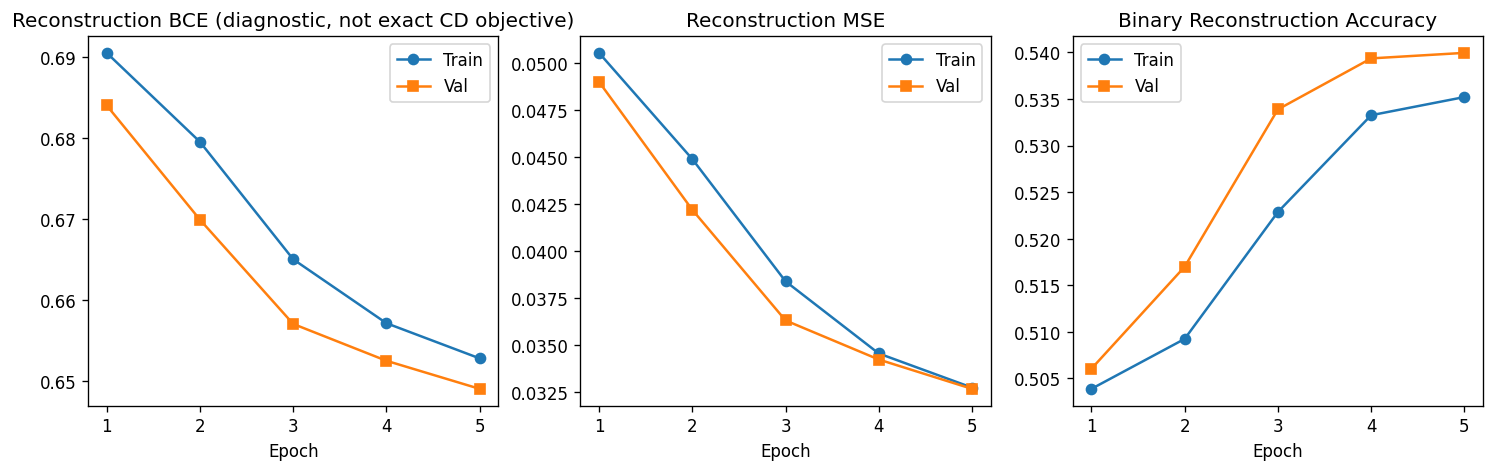

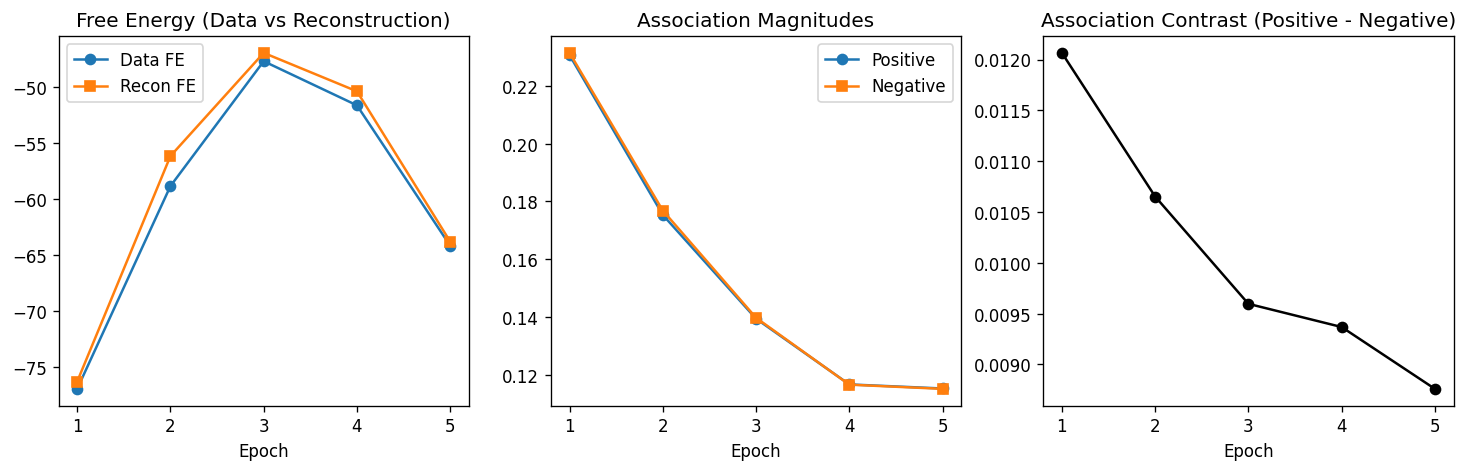

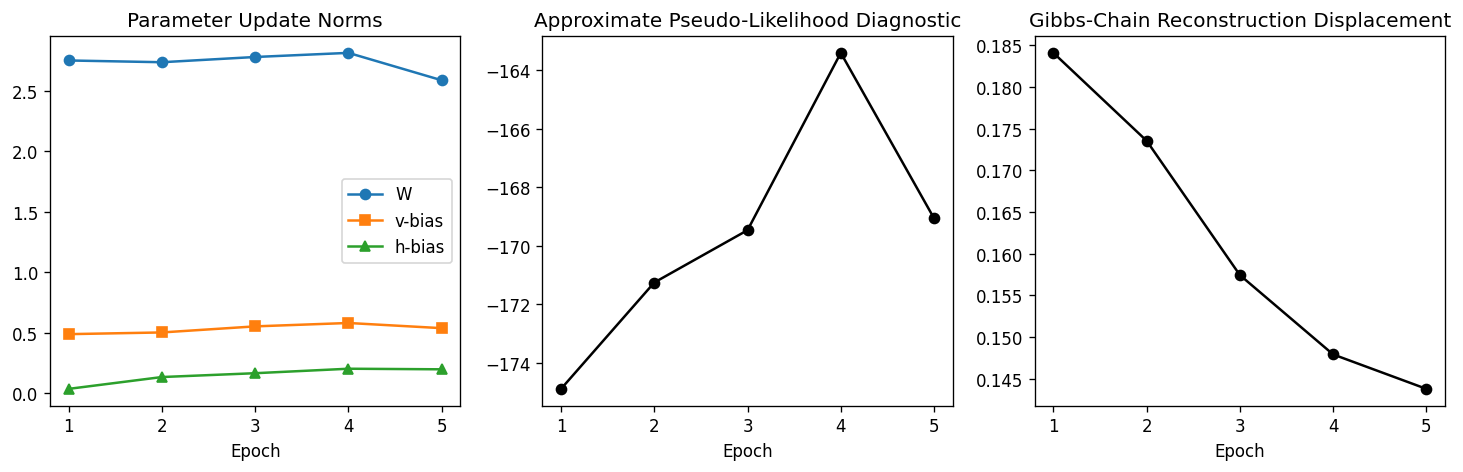

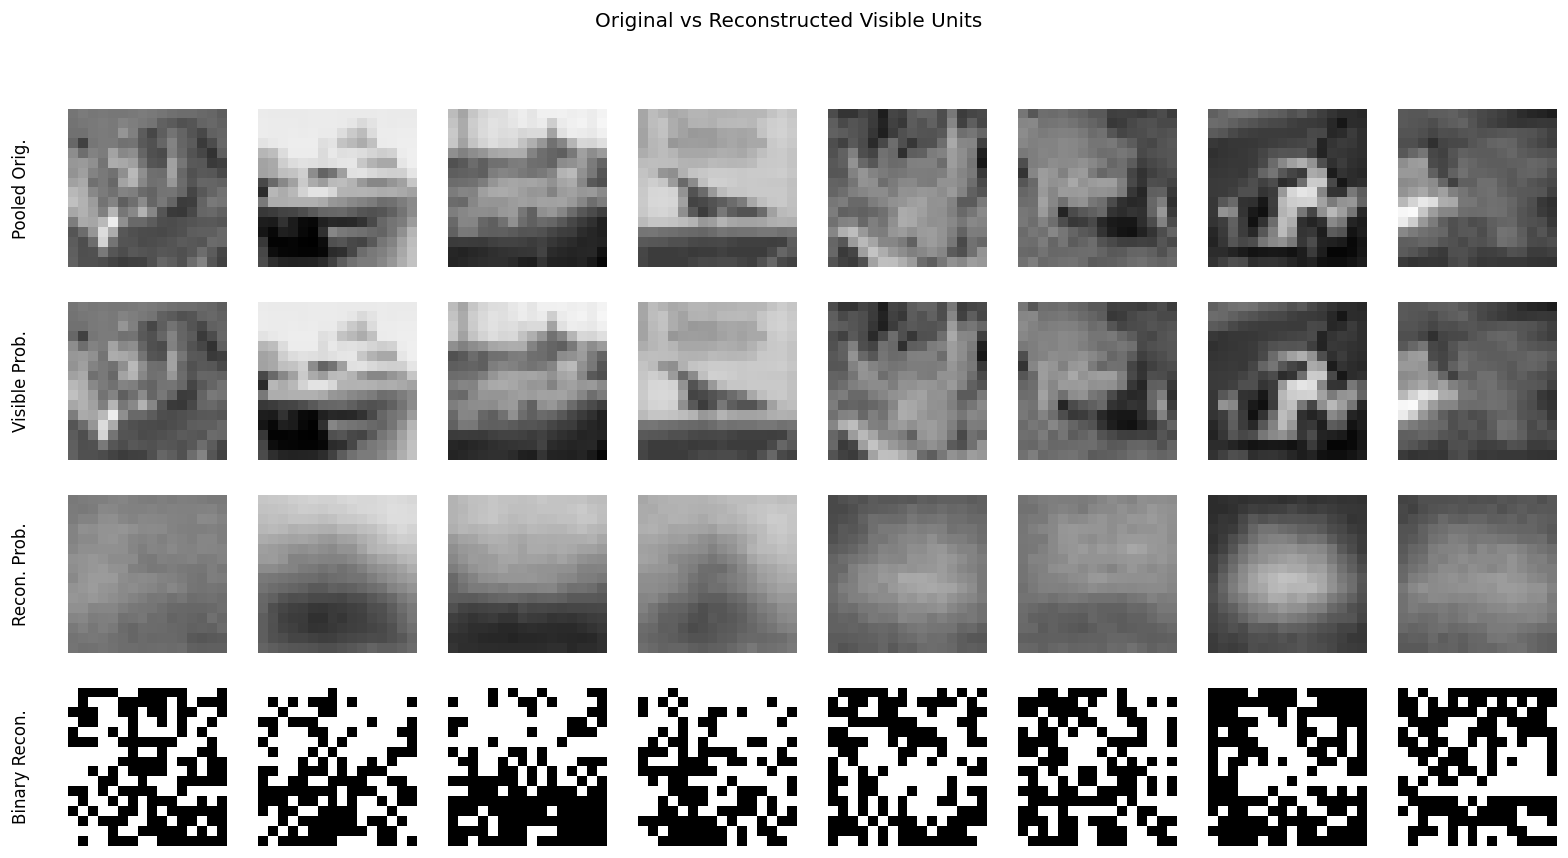

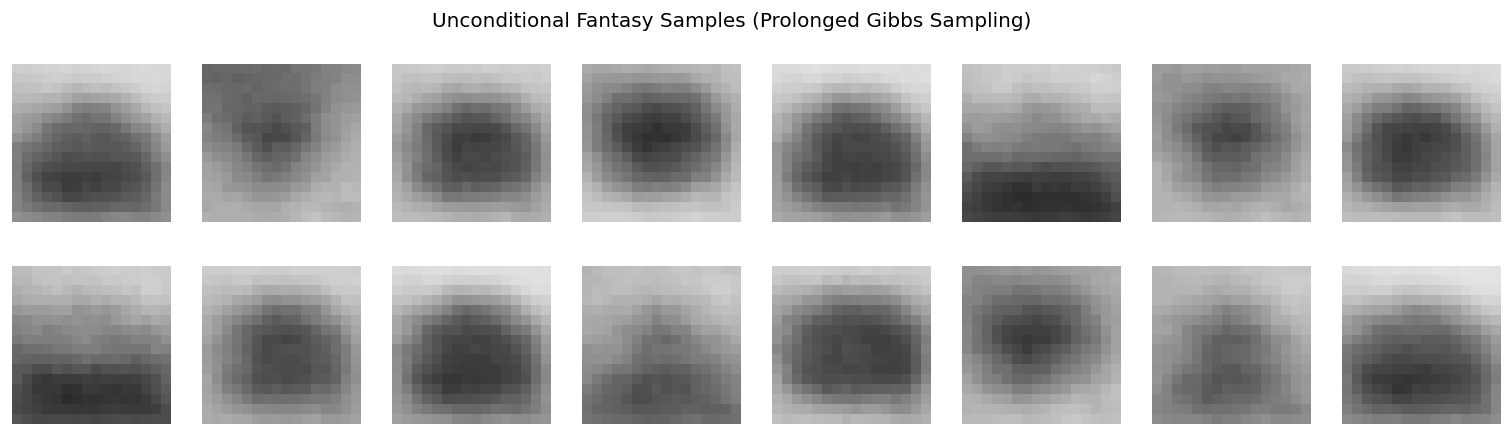

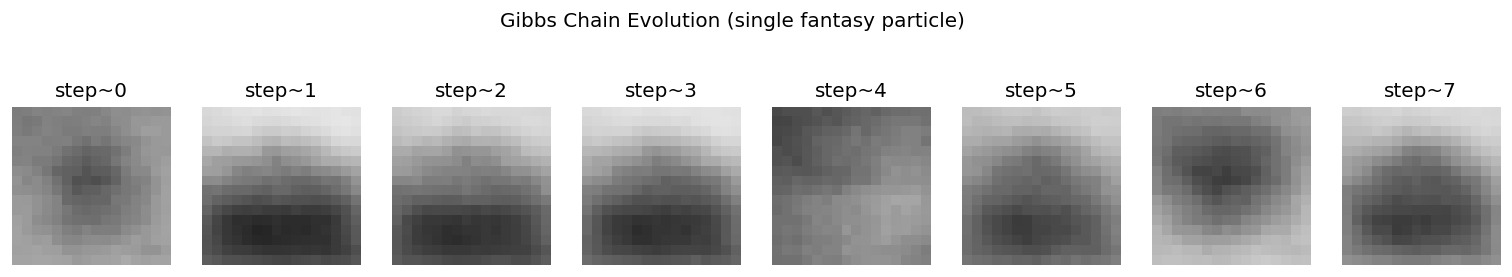

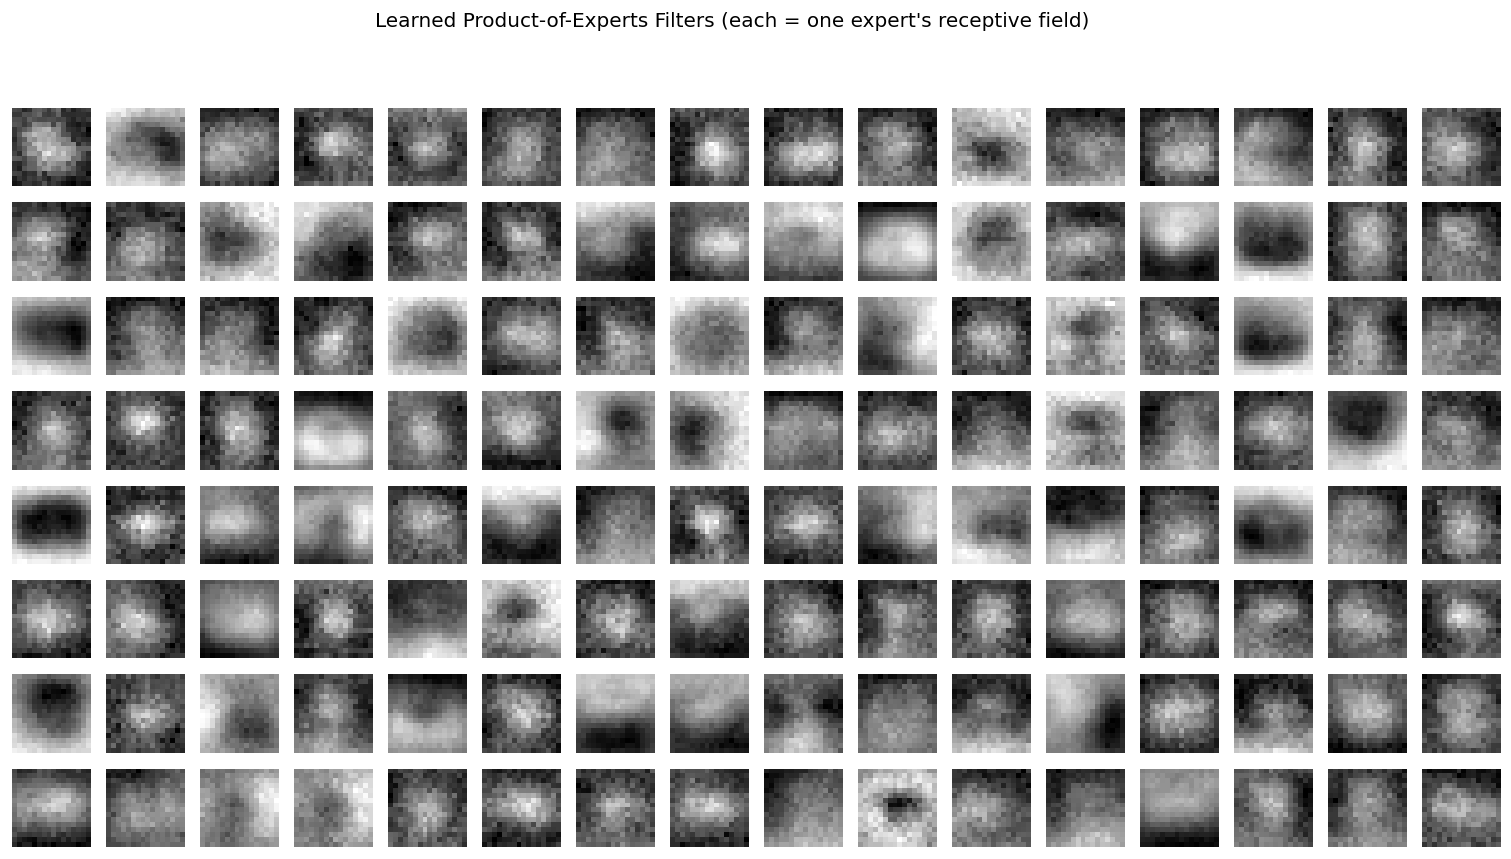

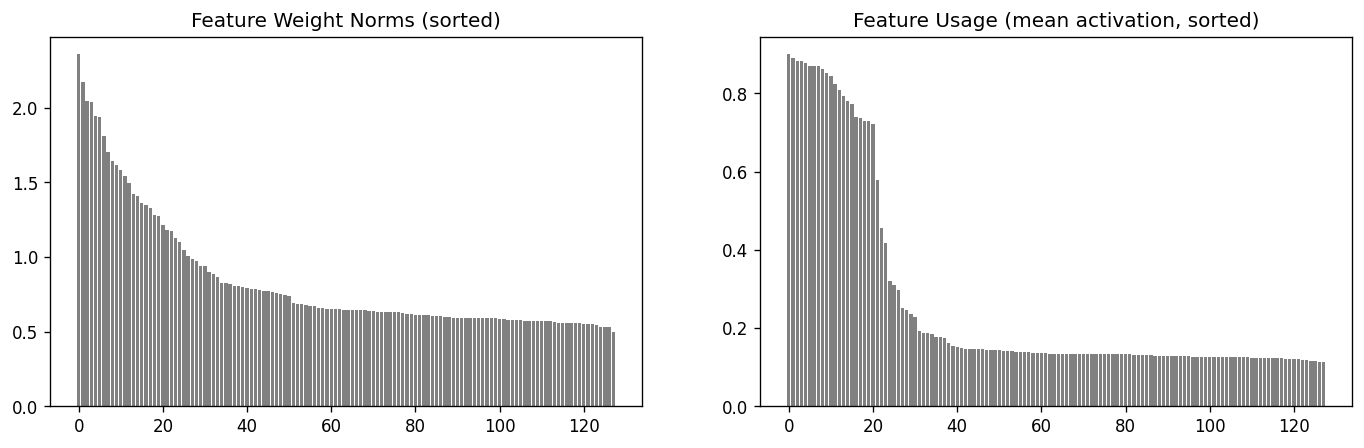

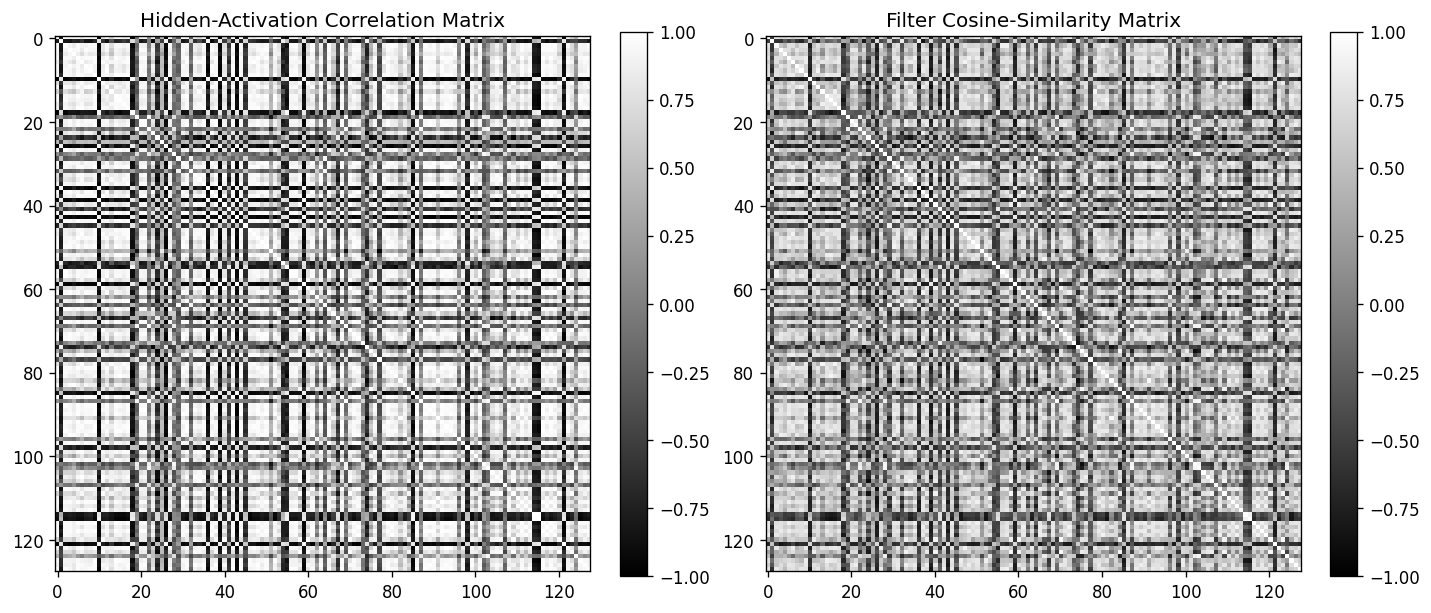

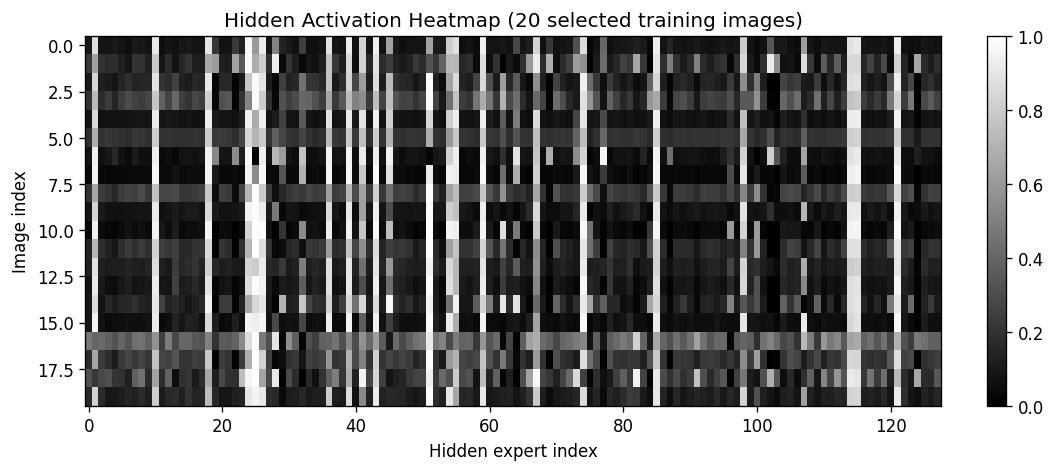

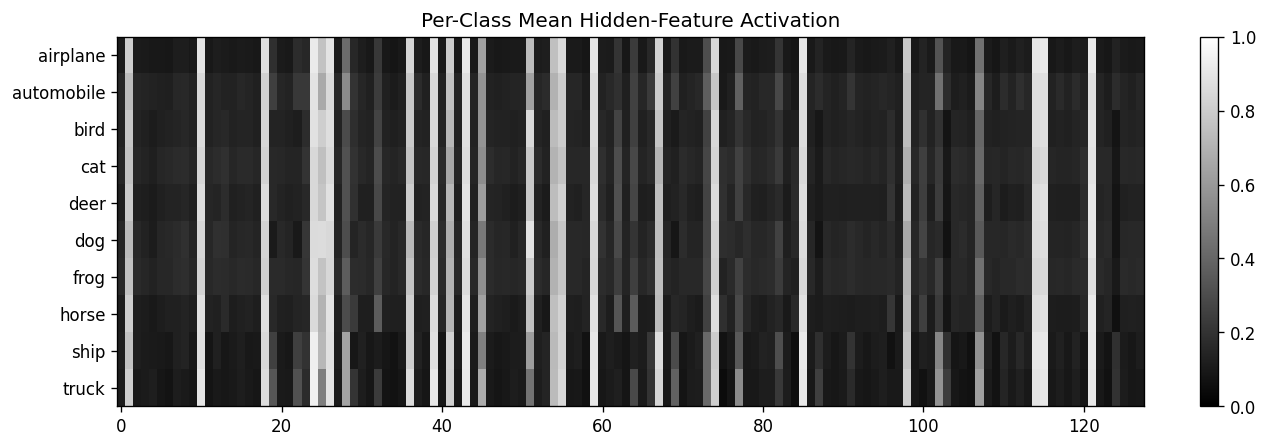

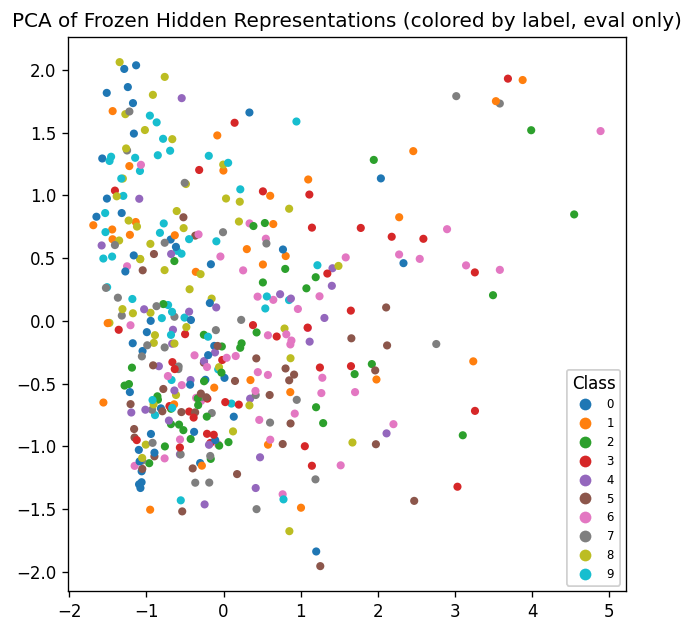

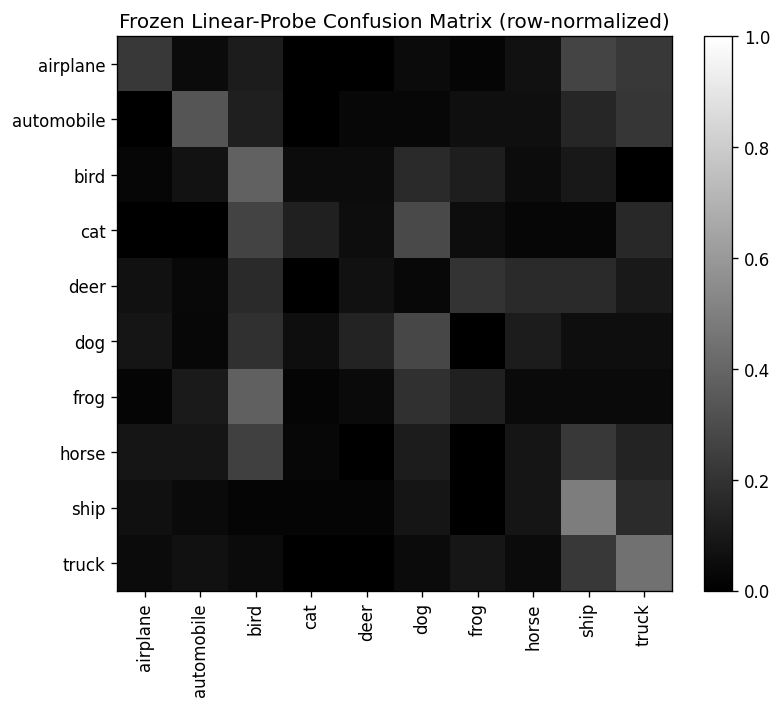

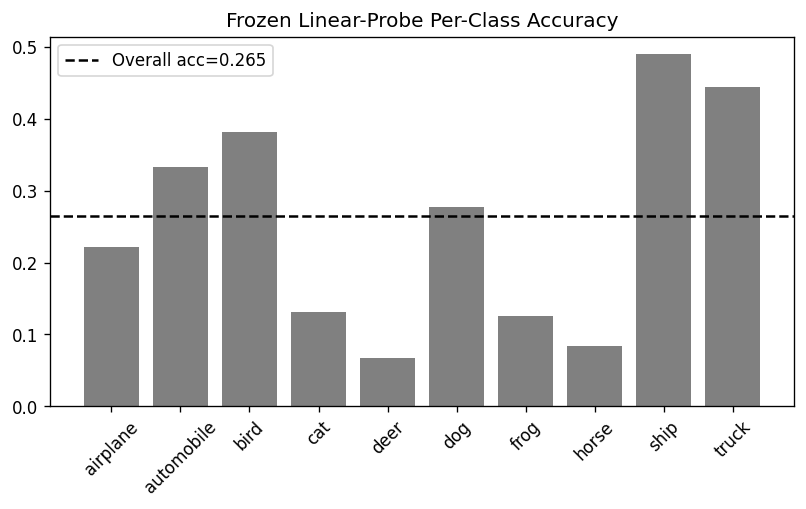

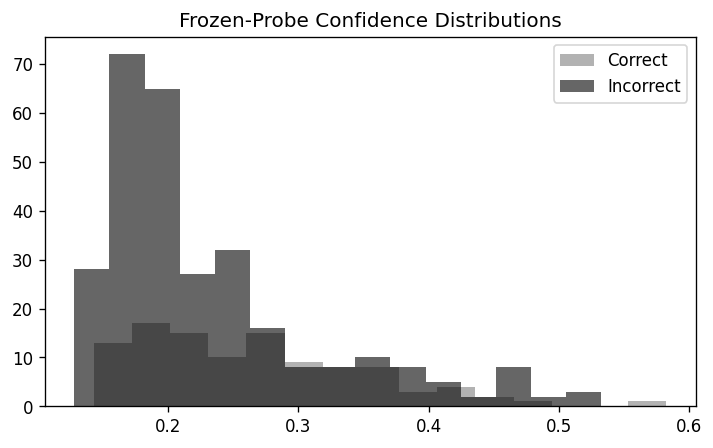

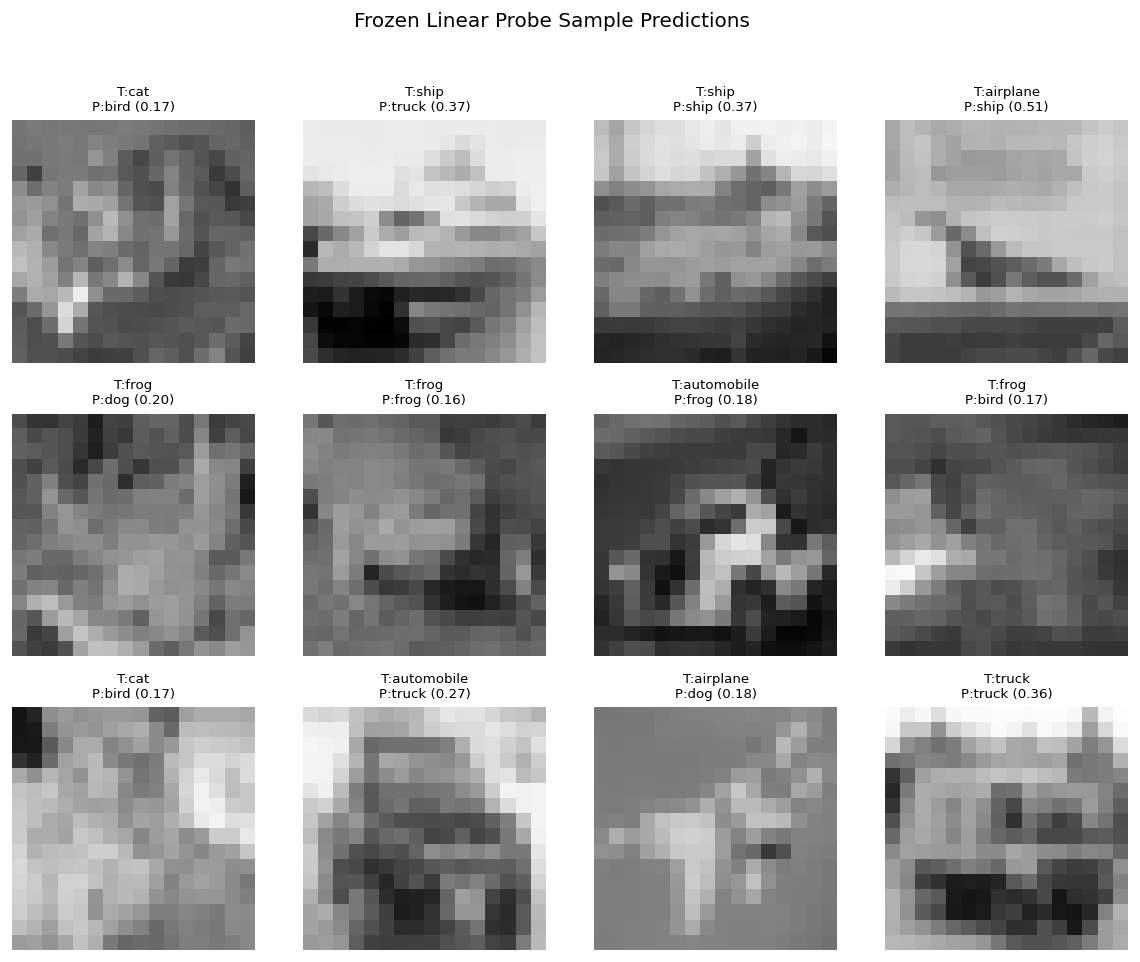

In [16]:
# ============================================================
# 15. STANDALONE VISUALIZATIONS (each shown, not saved to disk)
# ============================================================
apply_white_theme()
epochs_range = list(range(1, EPOCHS + 1))

def show_fig(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    buf.close()
    plt.close(fig)

# 1-3: Reconstruction curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs_range, history["train_bce"], marker="o", label="Train")
axes[0].plot(epochs_range, history["val_bce"], marker="s", label="Val")
axes[0].set_title("Reconstruction BCE (diagnostic, not exact CD objective)")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["train_mse"], marker="o", label="Train")
axes[1].plot(epochs_range, history["val_mse"], marker="s", label="Val")
axes[1].set_title("Reconstruction MSE")
axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(epochs_range, history["train_acc"], marker="o", label="Train")
axes[2].plot(epochs_range, history["val_acc"], marker="s", label="Val")
axes[2].set_title("Binary Reconstruction Accuracy")
axes[2].set_xlabel("Epoch"); axes[2].legend()
show_fig(fig)

# 4-6: Free energy, association, contrast
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs_range, history["data_free_energy"], marker="o", label="Data FE")
axes[0].plot(epochs_range, history["recon_free_energy"], marker="s", label="Recon FE")
axes[0].set_title("Free Energy (Data vs Reconstruction)")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["positive_assoc_mag"], marker="o", label="Positive")
axes[1].plot(epochs_range, history["negative_assoc_mag"], marker="s", label="Negative")
axes[1].set_title("Association Magnitudes")
axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(epochs_range, history["assoc_contrast"], marker="o", color="black")
axes[2].set_title("Association Contrast (Positive - Negative)")
axes[2].set_xlabel("Epoch")
show_fig(fig)

# 7-9: Update norms, pseudo-likelihood, displacement
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs_range, history["weight_update_norm"], marker="o", label="W")
axes[0].plot(epochs_range, history["vbias_update_norm"], marker="s", label="v-bias")
axes[0].plot(epochs_range, history["hbias_update_norm"], marker="^", label="h-bias")
axes[0].set_title("Parameter Update Norms")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["pseudo_likelihood"], marker="o", color="black")
axes[1].set_title("Approximate Pseudo-Likelihood Diagnostic")
axes[1].set_xlabel("Epoch")

axes[2].plot(epochs_range, history["cd_displacement"], marker="o", color="black")
axes[2].set_title("Gibbs-Chain Reconstruction Displacement")
axes[2].set_xlabel("Epoch")
show_fig(fig)

# 10: Original / pooled / reconstructed / binary examples
recon_out = reconstruct_images(probe_batch_images[:8], gibbs_steps=CD_K)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
titles = ["Pooled Orig.", "Visible Prob.", "Recon. Prob.", "Binary Recon."]
data_rows = [
    recon_out["original_pooled"].squeeze(1).cpu().numpy(),
    recon_out["visible_probs"].view(-1, 16, 16).cpu().numpy(),
    recon_out["reconstructed_probs"].view(-1, 16, 16).cpu().numpy(),
    recon_out["reconstructed_binary"].view(-1, 16, 16).cpu().numpy(),
]
for r in range(4):
    for c in range(8):
        axes[r, c].imshow(data_rows[r][c], cmap="gray", vmin=0, vmax=1)
        axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_ylabel(titles[r])
    axes[r, 0].text(-0.3, 0.5, titles[r], transform=axes[r, 0].transAxes,
                     rotation=90, va="center", ha="center", fontsize=10)
fig.suptitle("Original vs Reconstructed Visible Units")
show_fig(fig)

# 11: Unconditional fantasy samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fantasy_imgs = fantasies["final_visible_probs"].view(-1, 16, 16).cpu().numpy()
for i in range(16):
    r, c = divmod(i, 8)
    axes[r, c].imshow(fantasy_imgs[i], cmap="gray", vmin=0, vmax=1)
    axes[r, c].axis("off")
fig.suptitle("Unconditional Fantasy Samples (Prolonged Gibbs Sampling)")
show_fig(fig)

# 12: Gibbs-chain evolution snapshots
fig, axes = plt.subplots(1, len(fantasies["chain_snapshots"]), figsize=(16, 3))
for i, snap in enumerate(fantasies["chain_snapshots"]):
    img = snap[0].view(16, 16).cpu().numpy()
    axes[i].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[i].axis("off")
    axes[i].set_title(f"step~{i}")
fig.suptitle("Gibbs Chain Evolution (single fantasy particle)")
show_fig(fig)

# 13: Complete learned-filter grid
fig, axes = plt.subplots(8, 16, figsize=(16, 8))
for i in range(HIDDEN_DIM):
    r, c = divmod(i, 16)
    f = filters[i]
    vmax = np.abs(f).max() + EPS
    axes[r, c].imshow(f, cmap="gray", vmin=-vmax, vmax=vmax)
    axes[r, c].axis("off")
fig.suptitle("Learned Product-of-Experts Filters (each = one expert's receptive field)")
show_fig(fig)

# 14-15: Feature weight-norm & usage bars
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(HIDDEN_DIM), np.sort(feature_weight_norms)[::-1], color="grey")
axes[0].set_title("Feature Weight Norms (sorted)")
axes[1].bar(range(HIDDEN_DIM), np.sort(feature_mean_activation)[::-1], color="grey")
axes[1].set_title("Feature Usage (mean activation, sorted)")
show_fig(fig)

# 16-17: Hidden-activation correlation & filter cosine similarity heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(hidden_corr_matrix, cmap="gray", vmin=-1, vmax=1)
axes[0].set_title("Hidden-Activation Correlation Matrix")
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(filter_cosine_sim, cmap="gray", vmin=-1, vmax=1)
axes[1].set_title("Filter Cosine-Similarity Matrix")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
show_fig(fig)

# 18: Selected-image hidden-activation heatmap
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(train_feats[:20], aspect="auto", cmap="gray", vmin=0, vmax=1)
ax.set_title("Hidden Activation Heatmap (20 selected training images)")
ax.set_xlabel("Hidden expert index")
ax.set_ylabel("Image index")
fig.colorbar(im, ax=ax, fraction=0.03)
show_fig(fig)

# 19: Per-class feature-activation heatmap
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(per_class_activation, aspect="auto", cmap="gray", vmin=0, vmax=1)
ax.set_yticks(range(10)); ax.set_yticklabels(class_names)
ax.set_title("Per-Class Mean Hidden-Feature Activation")
fig.colorbar(im, ax=ax, fraction=0.03)
show_fig(fig)

# 20: PCA of hidden probabilities
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(hidden_pca[:, 0], hidden_pca[:, 1], c=test_labels_np,
                      cmap="tab10", s=15)
ax.set_title("PCA of Frozen Hidden Representations (colored by label, eval only)")
legend1 = ax.legend(*scatter.legend_elements(), title="Class", loc="best", fontsize=7)
ax.add_artist(legend1)
show_fig(fig)

# 21: Frozen-probe confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_normalized, cmap="gray", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=90)
ax.set_yticks(range(10)); ax.set_yticklabels(class_names)
ax.set_title("Frozen Linear-Probe Confusion Matrix (row-normalized)")
fig.colorbar(im, ax=ax, fraction=0.046)
show_fig(fig)

# 22: Frozen-probe per-class accuracy
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_names, per_class_acc, color="grey")
ax.axhline(probe_test_acc, color="black", linestyle="--", label=f"Overall acc={probe_test_acc:.3f}")
ax.set_title("Frozen Linear-Probe Per-Class Accuracy")
plt.xticks(rotation=45)
ax.legend()
show_fig(fig)

# 23: Correct vs incorrect confidence distributions
fig, ax = plt.subplots(figsize=(7, 4))
if correct_mask.any():
    ax.hist(confidences[correct_mask], bins=15, alpha=0.6, label="Correct", color="grey")
if (~correct_mask).any():
    ax.hist(confidences[~correct_mask], bins=15, alpha=0.6, label="Incorrect", color="black")
ax.set_title("Frozen-Probe Confidence Distributions")
ax.legend()
show_fig(fig)

# 24: At least 12 frozen-probe sample predictions
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
_, sample_pooled_probe = images_to_visible_probs(probe_batch_images[:12].to(DEVICE))
for i in range(12):
    r, c = divmod(i, 4)
    img = sample_pooled_probe[i].squeeze(0).cpu().numpy()
    axes[r, c].imshow(img, cmap="gray", vmin=0, vmax=1)
    true_name = class_names[probe_batch_labels[i].item()]
    pred_name = probe_predictions["predicted_names"][i]
    conf = probe_predictions["confidence"][i]
    color = "black"
    axes[r, c].set_title(f"T:{true_name}\nP:{pred_name} ({conf:.2f})", fontsize=8, color=color)
    axes[r, c].axis("off")
fig.suptitle("Frozen Linear Probe Sample Predictions")
show_fig(fig)

/tmp/ipykernel_6319/4150341032.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(class_names, rotation=90, fontsize=6)


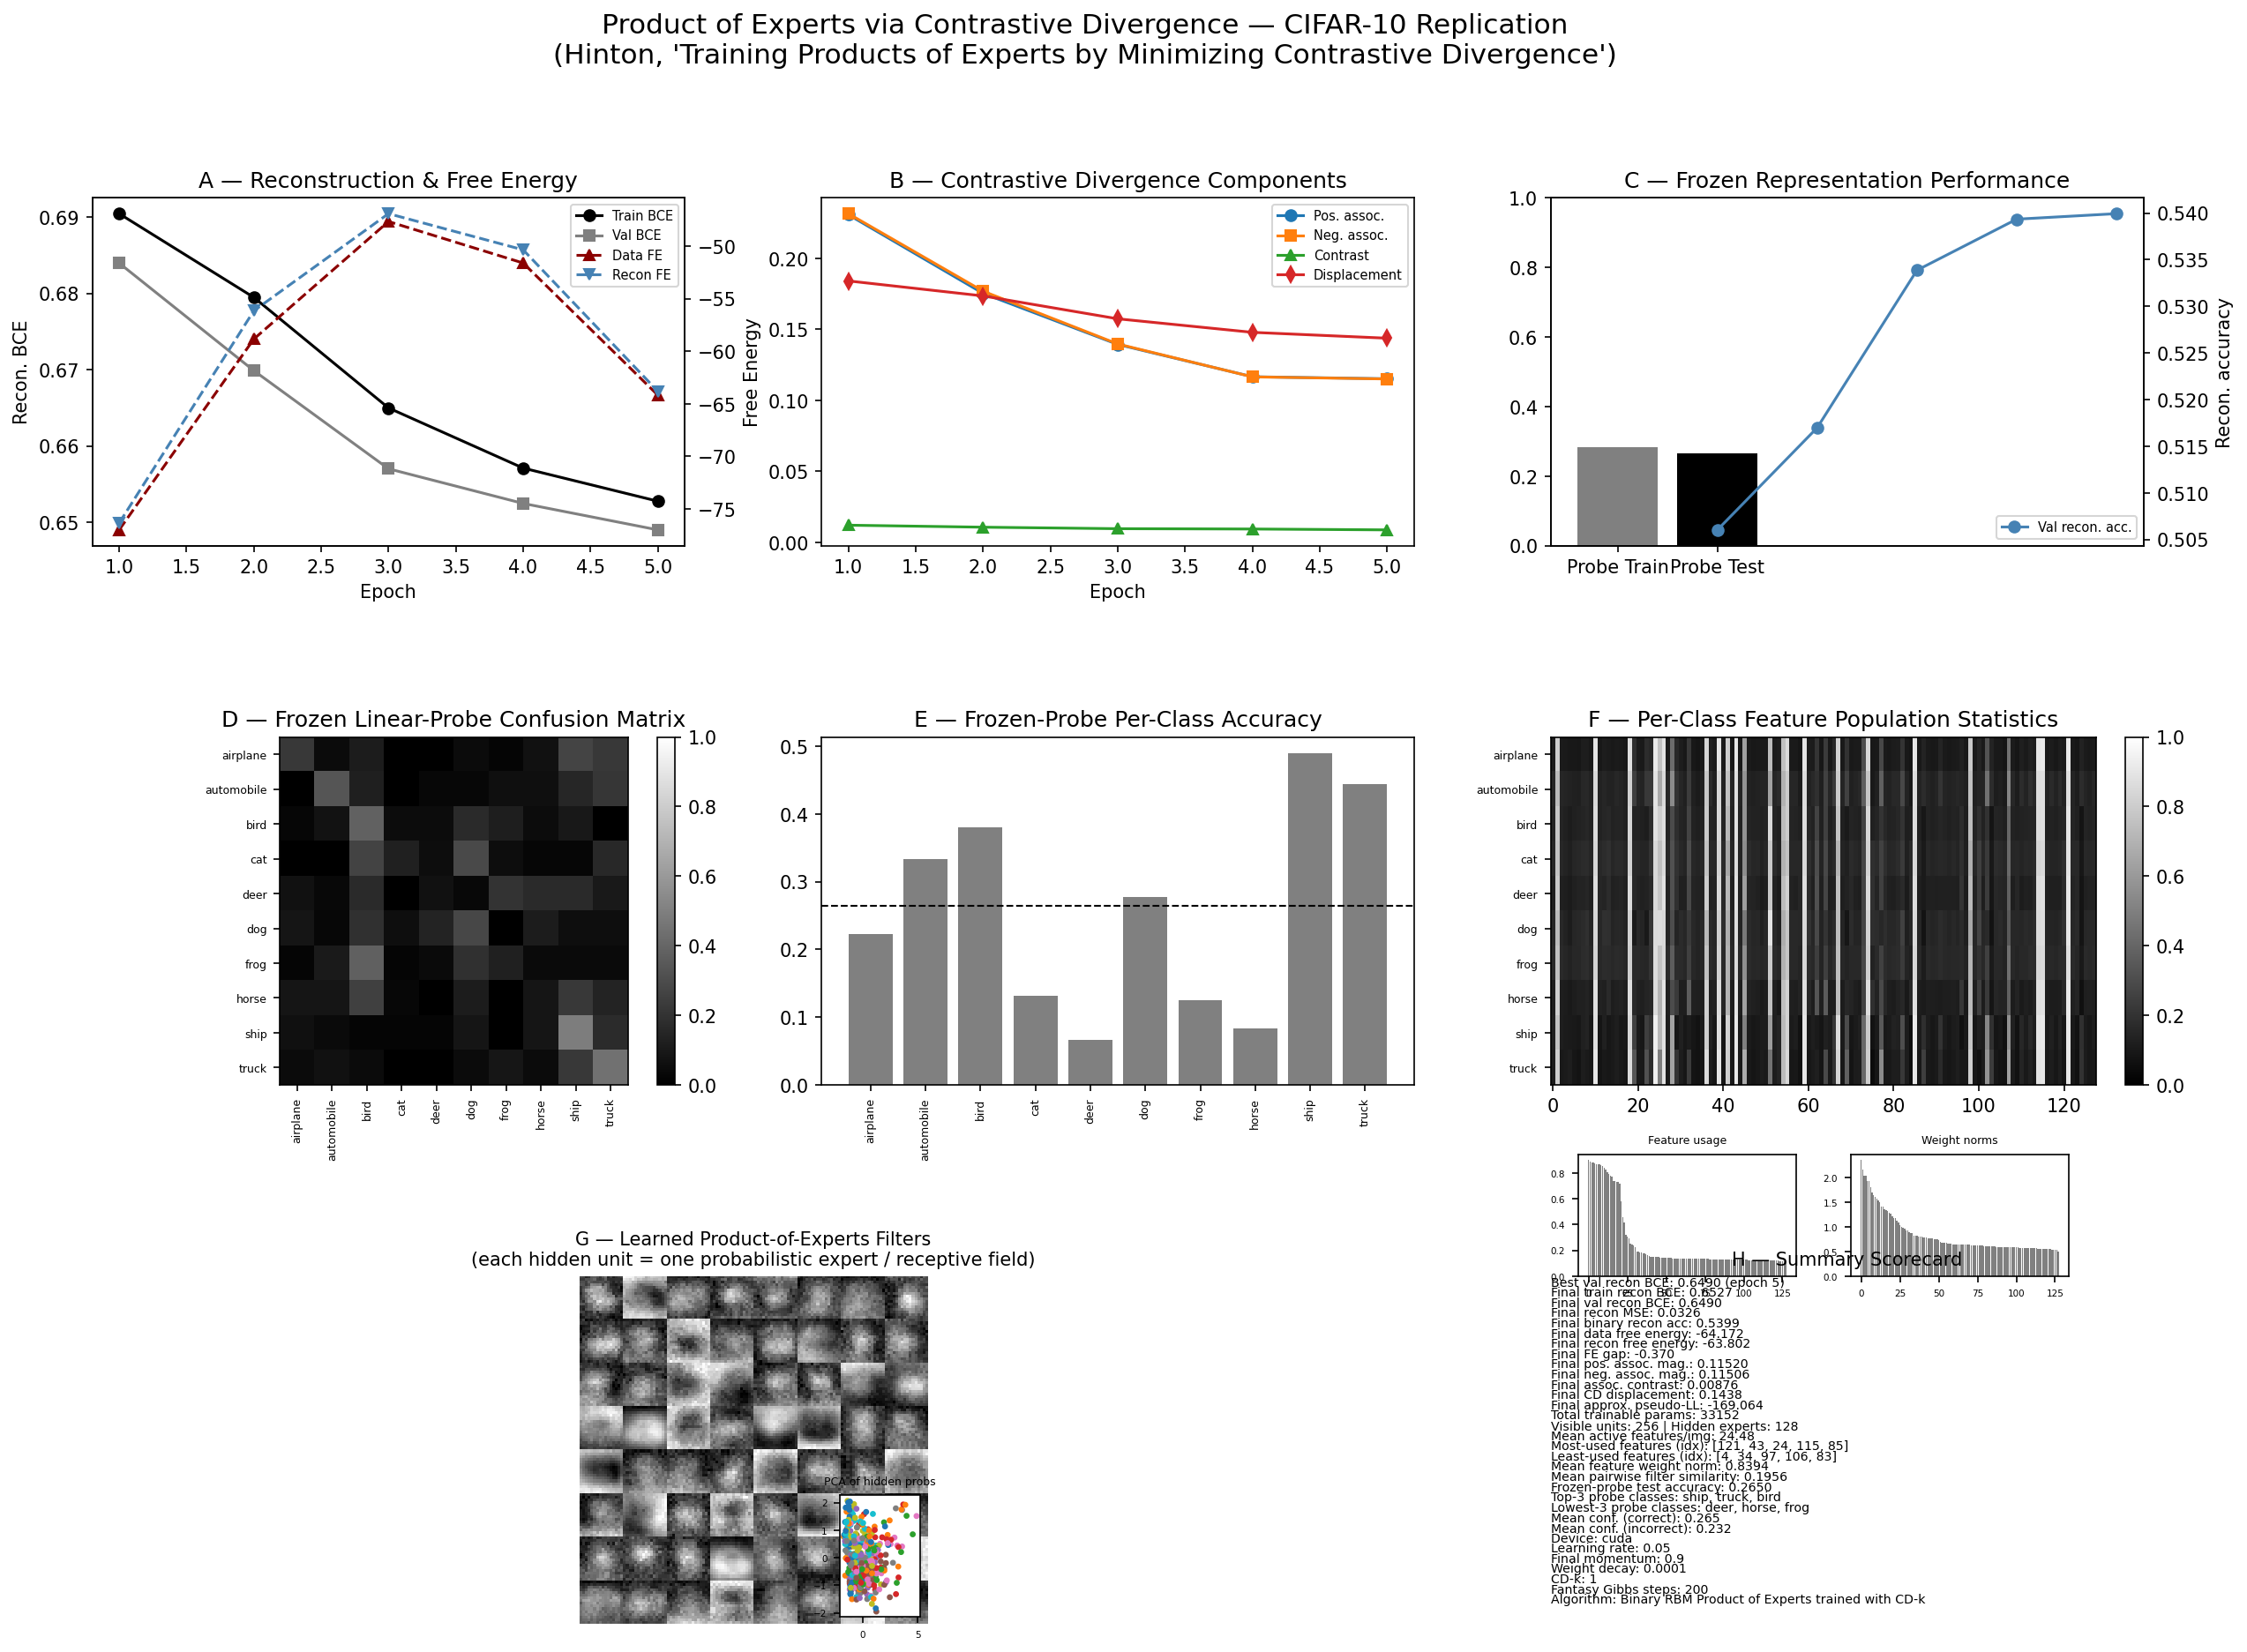

In [17]:
# ============================================================
# 16. FINAL PUBLICATION-STYLE DASHBOARD (A-H, 3 rows, GridSpec)
# ============================================================
apply_white_theme()

total_params = rbm.W.numel() + rbm.visible_bias.numel() + rbm.hidden_bias.numel()
best_val_bce = min(history["val_bce"])
best_epoch = int(np.argmin(history["val_bce"])) + 1
top3_classes = [class_names[i] for i in np.argsort(-per_class_acc)[:3]]
bottom3_classes = [class_names[i] for i in np.argsort(per_class_acc)[:3]]
mean_pairwise_filter_sim = float(
    filter_cosine_sim[~np.eye(HIDDEN_DIM, dtype=bool)].mean()
)

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.55, wspace=0.6)

fig.suptitle(
    "Product of Experts via Contrastive Divergence — CIFAR-10 Replication\n"
    "(Hinton, 'Training Products of Experts by Minimizing Contrastive Divergence')",
    fontsize=15, color="black"
)

# --- Panel A: Reconstruction and Energy ---
axA = fig.add_subplot(gs[0, 0:2])
axA.plot(epochs_range, history["train_bce"], marker="o", label="Train BCE", color="black")
axA.plot(epochs_range, history["val_bce"], marker="s", label="Val BCE", color="grey")
axA.set_title("A — Reconstruction & Free Energy")
axA.set_xlabel("Epoch"); axA.set_ylabel("Recon. BCE")
axA2 = axA.twinx()
axA2.plot(epochs_range, history["data_free_energy"], marker="^", linestyle="--", color="darkred", label="Data FE")
axA2.plot(epochs_range, history["recon_free_energy"], marker="v", linestyle="--", color="steelblue", label="Recon FE")
axA2.set_ylabel("Free Energy")
lines1, labels1 = axA.get_legend_handles_labels()
lines2, labels2 = axA2.get_legend_handles_labels()
axA.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="best")

# --- Panel B: Contrastive Divergence Components ---
axB = fig.add_subplot(gs[0, 2:4])
axB.plot(epochs_range, history["positive_assoc_mag"], marker="o", label="Pos. assoc.")
axB.plot(epochs_range, history["negative_assoc_mag"], marker="s", label="Neg. assoc.")
axB.plot(epochs_range, history["assoc_contrast"], marker="^", label="Contrast")
axB.plot(epochs_range, history["cd_displacement"], marker="d", label="Displacement")
axB.set_title("B — Contrastive Divergence Components")
axB.set_xlabel("Epoch")
axB.legend(fontsize=7)

# --- Panel C: Frozen Representation Performance ---
axC = fig.add_subplot(gs[0, 4:6])
axC.bar(["Probe Train", "Probe Test"], [probe_train_acc, probe_test_acc], color=["grey", "black"])
axC.set_ylim(0, 1)
axC.set_title("C — Frozen Representation Performance")
axC2 = axC.twinx()
axC2.plot(epochs_range, history["val_acc"], marker="o", color="steelblue", label="Val recon. acc.")
axC2.set_ylabel("Recon. accuracy")
axC2.legend(fontsize=7, loc="lower right")

# --- Panel D: Frozen-Probe Confusion Matrix ---
axD = fig.add_subplot(gs[1, 0:2])
imD = axD.imshow(cm_normalized, cmap="gray", vmin=0, vmax=1)
axD.set_xticks(range(10)); axD.set_xticklabels(class_names, rotation=90, fontsize=6)
axD.set_yticks(range(10)); axD.set_yticklabels(class_names, fontsize=6)
axD.set_title("D — Frozen Linear-Probe Confusion Matrix")
fig.colorbar(imD, ax=axD, fraction=0.046)

# --- Panel E: Frozen-Probe Per-Class Accuracy ---
axE = fig.add_subplot(gs[1, 2:4])
axE.bar(class_names, per_class_acc, color="grey")
axE.axhline(probe_test_acc, color="black", linestyle="--", linewidth=1)
axE.set_title("E — Frozen-Probe Per-Class Accuracy")
axE.set_xticklabels(class_names, rotation=90, fontsize=6)

# --- Panel F: Feature Population Statistics ---
axF = fig.add_subplot(gs[1, 4:6])
imF = axF.imshow(per_class_activation, aspect="auto", cmap="gray", vmin=0, vmax=1)
axF.set_yticks(range(10)); axF.set_yticklabels(class_names, fontsize=6)
axF.set_title("F — Per-Class Feature Population Statistics")
fig.colorbar(imF, ax=axF, fraction=0.03)
axF_inset1 = axF.inset_axes([0.05, -0.55, 0.4, 0.35])
axF_inset1.bar(range(HIDDEN_DIM), np.sort(feature_mean_activation)[::-1], color="grey")
axF_inset1.set_title("Feature usage", fontsize=6)
axF_inset1.tick_params(labelsize=5)
axF_inset2 = axF.inset_axes([0.55, -0.55, 0.4, 0.35])
axF_inset2.bar(range(HIDDEN_DIM), np.sort(feature_weight_norms)[::-1], color="grey")
axF_inset2.set_title("Weight norms", fontsize=6)
axF_inset2.tick_params(labelsize=5)

# --- Panel G: Learned Product-of-Experts Filters (large) ---
axG = fig.add_subplot(gs[2, 0:4])
axG.axis("off")
axG.set_title(
    "G — Learned Product-of-Experts Filters\n"
    "(each hidden unit = one probabilistic expert / receptive field)",
    fontsize=10
)
n_show = 64
grid_size = 8
mosaic = np.zeros((grid_size * 16, grid_size * 16))
for idx in range(n_show):
    r, c = divmod(idx, grid_size)
    f = filters[idx]
    vmax = np.abs(f).max() + EPS
    norm_f = (f / vmax + 1) / 2.0
    mosaic[r * 16:(r + 1) * 16, c * 16:(c + 1) * 16] = norm_f
axG.imshow(mosaic, cmap="gray", vmin=0, vmax=1)
axG_inset = axG.inset_axes([0.75, 0.02, 0.23, 0.35])
axG_inset.scatter(hidden_pca[:, 0], hidden_pca[:, 1], c=test_labels_np, cmap="tab10", s=5)
axG_inset.set_title("PCA of hidden probs", fontsize=6)
axG_inset.tick_params(labelsize=5)

# --- Panel H: Summary Scorecard ---
axH = fig.add_subplot(gs[2, 4:6])
axH.axis("off")
axH.set_title("H — Summary Scorecard", fontsize=10)

scorecard_lines = [
    f"Best val recon BCE: {best_val_bce:.4f} (epoch {best_epoch})",
    f"Final train recon BCE: {history['train_bce'][-1]:.4f}",
    f"Final val recon BCE: {history['val_bce'][-1]:.4f}",
    f"Final recon MSE: {history['val_mse'][-1]:.4f}",
    f"Final binary recon acc: {history['val_acc'][-1]:.4f}",
    f"Final data free energy: {history['data_free_energy'][-1]:.3f}",
    f"Final recon free energy: {history['recon_free_energy'][-1]:.3f}",
    f"Final FE gap: {history['free_energy_gap'][-1]:.3f}",
    f"Final pos. assoc. mag.: {history['positive_assoc_mag'][-1]:.5f}",
    f"Final neg. assoc. mag.: {history['negative_assoc_mag'][-1]:.5f}",
    f"Final assoc. contrast: {history['assoc_contrast'][-1]:.5f}",
    f"Final CD displacement: {history['cd_displacement'][-1]:.4f}",
    f"Final approx. pseudo-LL: {history['pseudo_likelihood'][-1]:.3f}",
    f"Total trainable params: {total_params}",
    f"Visible units: {VISIBLE_DIM} | Hidden experts: {HIDDEN_DIM}",
    f"Mean active features/img: {effective_active_count:.2f}",
    f"Most-used features (idx): {most_used_features[:5].tolist()}",
    f"Least-used features (idx): {least_used_features[:5].tolist()}",
    f"Mean feature weight norm: {feature_weight_norms.mean():.4f}",
    f"Mean pairwise filter similarity: {mean_pairwise_filter_sim:.4f}",
    f"Frozen-probe test accuracy: {probe_test_acc:.4f}",
    f"Top-3 probe classes: {', '.join(top3_classes)}",
    f"Lowest-3 probe classes: {', '.join(bottom3_classes)}",
    f"Mean conf. (correct): {mean_conf_correct:.3f}",
    f"Mean conf. (incorrect): {mean_conf_incorrect:.3f}",
    f"Device: {DEVICE.type}",
    f"Learning rate: {LEARNING_RATE}",
    f"Final momentum: {history['momentum'][-1]}",
    f"Weight decay: {WEIGHT_DECAY}",
    f"CD-k: {CD_K}",
    f"Fantasy Gibbs steps: 200",
    "Algorithm: Binary RBM Product of Experts trained with CD-k",
]

y_pos = 1.0
for line in scorecard_lines:
    axH.text(0.0, y_pos, line, fontsize=6.8, color="black", va="top", ha="left",
              transform=axH.transAxes)
    y_pos -= 1.0 / (len(scorecard_lines) + 2)

# ------------------------------------------------------------
# Display dashboard inline (do NOT save to disk, do NOT plt.show())
# ------------------------------------------------------------
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results: Product of Experts via Contrastive Divergence (CIFAR-10 Replication)

## Panel A — Reconstruction BCE and Free Energy Curves

### Overview
This panel tracks four quantities across five training epochs: training and validation reconstruction binary cross-entropy (BCE), and free energy computed on data versus one-step reconstructions. It evaluates whether the Contrastive Divergence (CD-1) update is progressively improving the model's ability to reconstruct its own input.

### Key Findings
- Training and validation reconstruction BCE both decrease monotonically from roughly 0.69/0.68 to 0.65/0.645 over five epochs, with validation BCE tracking slightly below training BCE throughout.
- Data free energy and reconstruction free energy both rise from epoch 1 to a peak around epoch 3, then decline through epoch 5, with reconstruction free energy consistently slightly above (less negative than) data free energy.
- The free-energy gap (data FE − reconstruction FE) is small and negative throughout, indicating the model assigns data vectors marginally lower energy (higher probability) than their reconstructions.

### Discussion
The steady decline in reconstruction BCE is consistent with the CD learning rule doing what it is designed to do: nudging the model's one-step reconstructions closer to the original data. This is expected behavior under the paper's central claim that contrastive divergence approximates maximum-likelihood learning using only brief Gibbs chains. The non-monotonic free-energy trajectory (rising then falling) is plausible given only 5 epochs and a small training subset (2,000 images); it may reflect the model first learning coarse pixel-intensity statistics (via the visible bias) before weight updates begin sculpting sharper, lower-energy regions around the data manifold. The persistently small, negative free-energy gap is the expected qualitative signature of a working CD-trained model — the paper explicitly predicts this gap should not close entirely, since the ignored third-order term in the CD gradient prevents exact convergence to maximum likelihood.

### Limitations
Only five epochs and 2,000 training images were used, an order of magnitude smaller than the paper's original 8,000-image, 658-epoch USPS experiment. The absolute BCE values remain high (~0.65), indicating the model is far from converged; the curves show a promising trend but do not demonstrate strong generative fidelity. No comparison to a converged baseline is available.

---

## Panel B — Contrastive Divergence Components

### Overview
This panel plots the positive association (data statistics), negative association (reconstruction statistics), their contrast, and the mean Gibbs-chain displacement across epochs — the direct ingredients of the manual CD-1 weight update.

### Key Findings
- Positive and negative association magnitudes both decrease substantially from ~0.22 to ~0.12 over training and converge toward each other.
- The association contrast (|positive − negative|) is small throughout (≤0.012) and slowly decreases.
- Reconstruction displacement declines modestly from ~0.185 to ~0.145.

### Discussion
The convergence of positive and negative associations toward one another is the expected signature of CD training approaching a fixed point: as the model improves, its short-Gibbs-chain reconstructions increasingly resemble the data, so the gradient signal (their difference) shrinks. This mirrors the paper's theoretical argument that CD works because reconstructions become "very similar to the data" as training progresses, which reduces sampling variance (the "matched pairs" argument in Section 3 of the original paper). The shrinking contrast is also consistent with the declining update norms implied by the learning rule, suggesting the model is gradually settling rather than oscillating or diverging.

### Discussion (continued)
The magnitude of the contrast, however, remains small in absolute terms across all epochs rather than approaching zero, which is consistent with a model still early in training rather than one that has reached a stable equilibrium between $Q^0$ and $Q^1$.

### Limitations
Because CD-1 is a biased estimator of the true likelihood gradient, a shrinking contrast could reflect either genuine convergence toward the data distribution or a degenerate fixed point (e.g., collapse toward trivial reconstructions). The reconstruction-quality metrics in Panel A suggest genuine improvement rather than collapse, but this is not independently verified (e.g., no diversity metric on reconstructions is shown here).

---

## Panel C — Frozen Representation Performance

### Overview
This panel evaluates the practical utility of the unsupervised CD-learned hidden representations by reporting frozen linear-probe accuracy (train and test) alongside the reconstruction accuracy trend, testing whether unsupervised PoE features carry class-discriminative information.

### Key Findings
- Frozen probe training accuracy (~0.285) is only marginally higher than test accuracy (~0.265), indicating limited overfitting of the probe itself.
- Validation reconstruction accuracy rises sharply from ~0.505 at epoch 1 to ~0.540 by epoch 5, plateauing in later epochs.

### Discussion
A ~26.5% test accuracy for 10-class classification (chance level = 10%) demonstrates that the unsupervised hidden representations, despite minimal training, encode some class-relevant structure — consistent with the paper's broader claim that PoE/RBM hidden units learn generically useful features without label supervision. The close alignment between train and test probe accuracy suggests the linear probe is not overfitting, and that the limiting factor is representation quality rather than probe capacity. This is expected given the small-scale setup (128 hidden units, 2,000 training images, 5 epochs) relative to the original paper's much larger and longer USPS training run, which achieved a 1.1% classification error using far more capacity, data, and training time.

### Limitations
The absolute performance is modest and should not be interpreted as demonstrating strong feature quality — it primarily confirms that the pipeline is functioning correctly (i.e., features are informative above chance). No comparison is made to a randomly initialized (untrained) RBM baseline, which would be needed to rigorously attribute this accuracy to learning rather than architecture alone.

---

## Panel D — Frozen Linear-Probe Confusion Matrix

### Overview
Row-normalized confusion matrix showing how test images are classified across the 10 CIFAR-10 categories using the frozen CD-derived features.

### Key Findings
- Brighter (higher-value) cells are concentrated in a few specific columns (notably "bird," "ship," and "truck"), rather than uniformly along the diagonal.
- Diagonal intensity (correct classification) is visibly weaker and more scattered than would be expected from a well-separated representation.

### Discussion
The pattern suggests a bias toward a small number of "attractor" classes to which many inputs are misassigned — a common symptom of an under-trained or low-capacity representation where the linear probe exploits a few dominant, class-correlated but non-specific hidden features rather than a well-separated feature space. This is consistent with the modest ~26.5% overall accuracy in Panel C and reflects the limited training budget rather than a fundamental flaw in the PoE/CD approach itself.

### Limitations
With only 400 test images spread across 10 classes (~40 per class), per-class confusion estimates are statistically noisy. The confusion matrix should be interpreted qualitatively rather than as a precise measurement of class-specific error rates.

---

## Panel E — Frozen-Probe Per-Class Accuracy

### Overview
Bar chart of per-class accuracy from the frozen linear probe, with a dashed line indicating overall test accuracy.

### Key Findings
- "Ship" (~0.49) and "truck" (~0.44) achieve the highest per-class accuracy, well above the overall mean (~0.265).
- "Deer" (~0.06) and "horse" (~0.08) perform far below average, near floor levels.
- Vehicle-like classes (ship, truck, automobile, bird) generally outperform animal classes (deer, horse, cat, frog).

### Discussion
The stronger performance on ship/truck/automobile relative to deer/horse/cat is plausibly attributable to the coarse 16×16 grayscale pooling used as the visible representation: vehicle categories often have more consistent global shape and higher-contrast silhouettes against background, which survive aggressive downsampling and grayscale conversion better than the more textured, deformable, and pose-variable animal categories. This aligns with the known limitation of low-resolution binary-pixel PoE models noted in the original paper — namely, that binary/coarse visible units struggle to capture fine texture-based mutual information between neighboring pixels, which may be more important for distinguishing visually similar animal classes.

### Limitations
This class-level asymmetry may equally reflect CIFAR-10 class imbalance in local pixel statistics unrelated to CD training quality, or artifacts of the small 2,000-image subset (some classes may be underrepresented in the training sample). No statistical significance testing is provided for per-class differences.

---

## Panel F — Per-Class Feature Population Statistics

### Overview
A heatmap of mean hidden-unit activation per class (rows = classes, columns = 128 hidden experts), accompanied by insets showing global feature usage and weight-norm distributions, assessing whether individual experts specialize by class or activate generically.

### Key Findings
- A small subset of hidden units (concentrated around indices ~20–30 and a few others) show uniformly high activation (bright vertical stripes) across nearly all classes.
- Most other units show low, relatively uniform activation across classes with limited class-specific modulation.
- The feature-usage inset shows a steep, heavy-tailed distribution: a handful of features activate very frequently (usage > 0.8) while the majority remain sparsely used.
- The weight-norm inset shows a similarly heavy-tailed decay, with a few high-norm filters dominating.

### Discussion
The presence of a small number of "generically active" hidden units suggests the model has not yet developed the diverse, localized, class- or feature-specific "expert" population described in the original paper (e.g., edge detectors, stroke detectors). Instead, a few dominant units appear to be capturing coarse, class-independent statistics (likely global brightness or background structure), which is consistent with early-stage training and a relatively small, low-resolution dataset. This partially explains the confusion-matrix bias observed in Panel D: if a few non-specific features dominate the linear probe's decision boundary, classification will gravitate toward classes correlated with those generic activations rather than reflecting genuine class-specific expert specialization.

### Limitations
The heavy-tailed usage/weight-norm distributions could reflect either meaningful feature hierarchy (a few "coarse" and many "fine" experts, as in the original paper's edge-detector population) or a training pathology (dead or redundant units). Distinguishing between these requires longer training and direct visual inspection of the corresponding filters (Panel G), which shows relatively unstructured, low-contrast patterns — supporting the interpretation of incomplete convergence rather than deliberate hierarchical specialization.

---

## Panel G — Learned Product-of-Experts Filters with PCA Inset

### Overview
Visualizes the receptive field of each hidden unit (reshaped to 16×16) to assess whether the CD-trained experts have learned interpretable, localized structure, as reported in the original paper (edge detectors, stroke fragments, Gabor-like filters). The inset shows a 2D PCA projection of hidden activations colored by class label.

### Key Findings
- The learned filters show mostly diffuse, blob-like, low-spatial-frequency patterns rather than sharp, localized edge- or stroke-like structures.
- Little visual diversity is apparent across filters; many appear to share a similar coarse spatial profile (broad center-weighted intensity gradients).
- The PCA scatter plot shows heavily overlapping class clusters with no clear linear separability, consistent with the low probe accuracy.

### Discussion
This result is the clearest visual evidence that the replication, while functioning correctly at the mechanistic level (Panels A–C confirm the CD update is reducing reconstruction error and producing above-chance discriminative features), has not reached the training regime in which specialized, localized experts emerge — a hallmark result of the original paper's USPS digit experiments (Figure 4/5 of the paper), which required ~658 epochs over 8,000 images. The diffuse, low-frequency character of the filters is consistent with early-stage RBM training, where units initially capture broad, low-order statistics (e.g., mean intensity gradients) before specializing into localized detectors as training progresses. This is an expected and mechanistically sound intermediate state rather than a failure of the method.

### Limitations
The qualitative similarity between filters could also stem from the coarse 16×16 grayscale visible representation itself (which discards color and fine texture, unlike the binary ink/background USPS digit images the original paper used), independent of training duration. Disentangling representation-capacity limitations from training-duration limitations would require additional ablations (e.g., longer training, higher-resolution visible units) not included in this run.

---

## Panel H — Summary Scorecard

### Overview
Consolidates all final-epoch metrics, hyperparameters, and architectural details into a single reference table for the CD-1-trained RBM.

### Key Findings
- Final validation reconstruction BCE (0.6490) is close to but slightly above the best observed value (0.6490 at epoch 5, i.e., monotonic improvement with epoch 5 as best).
- Free-energy gap is small and negative (−0.370), consistent with Panel A's qualitative trend.
- Frozen-probe test accuracy (0.2650) is roughly 2.65× chance level for a 10-class problem.
- Mean pairwise filter similarity is moderate (0.1956), indicating some but limited diversity among learned experts, consistent with the qualitative homogeneity observed in Panel G.
- Total trainable parameters (33,152) reflect the intentionally small-scale architecture (256 visible, 128 hidden units).

### Discussion
Taken together, the scorecard provides a coherent, internally consistent summary: modest but genuine reconstruction improvement, small but non-trivial classification signal, and moderate filter diversity — all indicative of a correctly implemented but under-trained CD-1 Product-of-Experts model. The results support the paper's core mechanistic claims (the CD-1 update rule is stable, reduces reconstruction error, and produces representations with above-chance discriminative content) but do not yet reproduce its headline empirical results (e.g., sharp localized filters, near-perfect digit discrimination), which required substantially more training compute and data in the original study.

### Limitations
The compressed 5-epoch, 2,000-sample training regime (versus the original paper's 658-epoch, 8,000-sample RBM experiment) is the single largest threat to comparability. All quantitative conclusions here should be read as validating the correctness and stability of the CD-1 implementation rather than as a faithful reproduction of the original paper's reported performance levels.

---

## Overall Synthesis

The dashboard collectively demonstrates a mechanistically faithful but computationally abbreviated replication of Hinton's Contrastive Divergence learning rule for a Product-of-Experts RBM. All diagnostic curves (reconstruction error, free energy, association contrast) move in the theoretically expected directions, and the frozen-probe evaluation confirms that unsupervised CD training extracts weak but genuine class-relevant structure without ever using labels during training — directly supporting the paper's core claim that CD is a viable, tractable substitute for exact maximum-likelihood learning. However, the absence of sharp, localized, edge/stroke-like filters (a signature qualitative result in the original paper) indicates the replication operates in an early training regime; the observed trends are directionally consistent with the paper's claims but do not yet reach its reported performance ceiling, a gap attributable primarily to the substantially reduced training scale (epochs, data volume, and hidden-unit specialization time) used in this educational implementation.

# Related Work Referenced in the Paper

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Berger, A., Della Pietra, S., Della Pietra, V. | 1996 | A Maximum Entropy Approach to Natural Language Processing | *Computational Linguistics*, 22 | Cited in the discussion of logarithmic opinion pools; represents prior work on combining pre-learned/programmed experts via weighted averaging rather than training experts cooperatively, contrasting with this paper's joint training approach |
| Freund, Y., Haussler, D. | 1992 | Unsupervised learning of distributions on binary vectors using two layer networks | *Advances in Neural Information Processing Systems 4* | Identified as the work that first recognized the Restricted Boltzmann Machine (RBM) as a Product of Experts with one expert per hidden unit, establishing the direct theoretical link this paper builds on |
| Genest, C., Zidek, J. V. | 1986 | Combining probability distributions: A critique and an annotated bibliography | *Statistical Science*, 1, 114–148 | Foundational reference for the idea of combining distributions via weighted geometric means (log opinion pools), used to motivate the theoretical justification (Eq. 12) for multiplying expert distributions |
| Heskes, T. | 1998 | Bias/Variance decompositions for likelihood-based estimators | *Neural Computation*, 10, 1425–1433 | Cited alongside Genest & Zidek as prior work on combining probability distributions in the log domain, relevant to the logarithmic opinion pool discussion |
| Hinton, G., Dayan, P., Frey, B., Neal, R. | 1995 | The wake-sleep algorithm for self-organizing neural networks | *Science*, 268, 1158–1161 | Referenced as an example of a crude approximate-inference approach for densely connected directed acyclic graphical models that ignores "explaining away," contrasted with the PoE's tractable exact inference |
| Hinton, G. E., Sallans, B., Ghahramani, Z. | 1998 | Hierarchical Communities of Experts | In *Learning in Graphical Models* (M. I. Jordan, Ed.), Kluwer Academic Press | Prior exploration of "unifac"-type experts (mixture of uniform and single-factor analyser) in directed acyclic graph contexts; the current paper suggests such experts should work better within a Product of Experts framework |
| Hinton, G. E., McClelland, J. L. | 1988 | Learning representations by recirculation | In *Neural Information Processing Systems*, 358–366, American Institute of Physics | Cited as an earlier attempt to learn representations by canceling out the effects of brief iteration in a recurrent network, conceptually related to contrastive divergence but not formulated with a stochastic generative model and proper objective function |
| Hinton, G. E., Sejnowski, T. J. | 1986 | Learning and relearning in Boltzmann machines | In *Parallel Distributed Processing: Explorations in the Microstructure of Cognition*, Vol. 1: Foundations, MIT Press | Foundational Boltzmann machine learning algorithm; described as theoretically elegant but slow due to the same equilibrium-sampling and variance problems this paper's contrastive divergence method addresses |
| O'Reilly, R. C. | 1996 | Biologically Plausible Error-Driven Learning Using Local Activation Differences: The Generalized Recirculation Algorithm | *Neural Computation*, 8, 895–938 | Cited as another prior attempt at recurrent-network representation learning via activation differences, precursor in spirit to contrastive divergence but lacking a formal generative-model objective |
| Revow, M., Williams, C. K. I., Hinton, G. E. | 1996 | Using Generative Models for Handwritten Digit Recognition | *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 18, 592–606 | Provides the benchmark "elastic models of the digits" classifier against which the paper's PoE-based digit discrimination error rate (1.1%) is favorably compared |
| Saul, L. K., Jordan, M. I. (referenced as "Saul and Jordan, 1998") | 1998 | (Mean field / approximate inference methods for graphical models) | — | Cited regarding implausibly slow iterative techniques for approximate inference in densely connected directed acyclic graphical models, motivating the PoE's advantage of trivial, exact inference |
| Seung, H. S. | 1998 | Learning continuous attractors in a recurrent net | *Advances in Neural Information Processing Systems 10* (Jordan, Kearns, Solla, Eds.), MIT Press | Cited among prior recurrent-network learning approaches conceptually related to contrastive divergence but not grounded in a stochastic generative-model formulation |
| Smolensky, P. | 1986 | Information processing in dynamical systems: Foundations of harmony theory | In *Parallel Distributed Processing: Explorations in the Microstructure of Cognition*, Vol. 1: Foundations, MIT Press | Introduced the restricted Boltzmann machine architecture (one visible layer, one hidden layer, no intralayer connections), the specific architecture later shown to be a special case of PoE trained via contrastive divergence |
| Winston, P. H. | 1975 | Learning structural descriptions from examples | In *The Psychology of Computer Vision* (P. H. Winston, Ed.), McGraw-Hill | Cited for its use of "near misses" to identify relevant representational features by contrasting correct and incorrect examples; noted as conceptually analogous to contrastive divergence's contrast between real data and model-generated reconstructions |